In [ ]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [ ]:
import warnings
warnings.filterwarnings('ignore')

import numpy as np
import pandas as pd

import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns

from sklearn.preprocessing import MinMaxScaler

import torch
import torch.nn as nn
from torch.utils.data import DataLoader, TensorDataset

from sklearn.metrics import (
    classification_report,
    roc_auc_score,
    average_precision_score,
    f1_score,
    precision_recall_curve,
    roc_curve,
)

from sklearn.decomposition import PCA
from sklearn.manifold import TSNE

SEED = 42
np.random.seed(SEED)
torch.manual_seed(SEED)

DEVICE = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {DEVICE}')

sns.set_theme(style='whitegrid', palette='muted')
plt.rcParams['figure.dpi'] = 120

print('All imports successful.')

Using device: cuda
All imports successful.


In [ ]:
NORMAL_PATH = '/content/drive/MyDrive/swat-dataset/normal.csv'
ATTACK_PATH  = '/content/drive/MyDrive/swat-dataset/attack.csv'

df_normal = pd.read_csv(NORMAL_PATH)
df_attack = pd.read_csv(ATTACK_PATH)

df_normal.columns = df_normal.columns.str.strip()
df_attack.columns = df_attack.columns.str.strip()

print('Normal shape :', df_normal.shape)
print('Attack shape :', df_attack.shape)
print()
print('Normal columns:')
print(df_normal.columns.tolist())
print()
print('Attack label distribution:')
print(df_attack['Normal/Attack'].value_counts())

Normal shape : (1387098, 53)
Attack shape : (54621, 53)

Normal columns:
['Timestamp', 'FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603', 'Normal/Attack']

Attack label distribution:
Normal/Attack
Attack    54621
Name: count, dtype: int64


In [ ]:
print('Normal file label distribution:')
print(df_normal['Normal/Attack'].value_counts())
print()

DROP_COLS = ['Timestamp', 'Normal/Attack']

feature_cols = [c for c in df_normal.columns if c not in DROP_COLS]
print(f'Feature columns ({len(feature_cols)}):')
print(feature_cols)
print()

 
print('Missing values in normal.csv:', df_normal[feature_cols].isnull().sum().sum())
print('Missing values in attack.csv:', df_attack[feature_cols].isnull().sum().sum())
print()

 
print('Any non-numeric feature columns in normal:')
print(df_normal[feature_cols].dtypes[df_normal[feature_cols].dtypes == object])

print('Any non-numeric feature columns in attack:')
print(df_attack[feature_cols].dtypes[df_attack[feature_cols].dtypes == object])

Normal file label distribution:
Normal/Attack
Normal    1387098
Name: count, dtype: int64

Feature columns (51):
['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P202', 'P203', 'P204', 'P205', 'P206', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P401', 'P402', 'P403', 'P404', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'P502', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P601', 'P602', 'P603']

Missing values in normal.csv: 6942600
Missing values in attack.csv: 0

Any non-numeric feature columns in normal:
Series([], dtype: object)
Any non-numeric feature columns in attack:
Series([], dtype: object)


In [ ]:
missing = df_normal[feature_cols].isnull().sum()
missing_pct = (missing / len(df_normal) * 100).round(4)

missing_report = pd.DataFrame({
    'missing_count': missing,
    'missing_pct': missing_pct
}).sort_values('missing_pct', ascending=False)

print('Top 20 features by missingness:')
print(missing_report[missing_report['missing_count'] > 0].head(20))
print()

df_normal[feature_cols] = (
    df_normal[feature_cols]
    .ffill()
    .bfill()
)

remaining = df_normal[feature_cols].isnull().sum().sum()
print(f'Missing values after fill: {remaining}')

Top 20 features by missingness:
        missing_count  missing_pct
MV101          991800      71.5018
P201           991800      71.5018
AIT201         991800      71.5018
P204           991800      71.5018
P202           991800      71.5018
MV201          991800      71.5018
MV303          991800      71.5018

Missing values after fill: 0


In [ ]:
first_valid_idx = df_normal[feature_cols].dropna().index[0]
print(f'First fully valid row index: {first_valid_idx}')
print(f'Rows before cutoff (dropped): {first_valid_idx}')
print(f'Rows after cutoff (kept): {len(df_normal) - first_valid_idx}')

df_normal = df_normal.loc[first_valid_idx:].reset_index(drop=True)

df_normal[feature_cols] = (
    df_normal[feature_cols]
    .ffill()
    .bfill()
)

print(f'\nClean normal data shape: {df_normal.shape}')
print(f'Missing values remaining: {df_normal[feature_cols].isnull().sum().sum()}')

flat_features = [c for c in feature_cols
                 if df_normal[c].nunique() == 1]
print(f'Constant (flat) features after cleaning: {flat_features}')

First fully valid row index: 0
Rows before cutoff (dropped): 0
Rows after cutoff (kept): 1387098

Clean normal data shape: (1387098, 53)
Missing values remaining: 0
Constant (flat) features after cleaning: ['P202', 'P204', 'P206', 'P401', 'P404', 'P502', 'P601', 'P603']


In [ ]:
constant_features = [c for c in feature_cols
                     if df_normal[c].nunique() == 1]
print(f'Dropping constant features ({len(constant_features)}):')
print(constant_features)

low_var = [c for c in feature_cols
           if c not in constant_features
           and df_normal[c].std() < 1e-4]
print(f'\nNear-constant features (std < 1e-4): {low_var}')

feature_cols = [c for c in feature_cols if c not in constant_features]

print(f'\nFinal feature set: {len(feature_cols)} features')
print(feature_cols)

print('\nVariance of dropped features in attack data:')
for col in constant_features:
    print(f'  {col}: {df_attack[col].nunique()} unique values')

Dropping constant features (8):
['P202', 'P204', 'P206', 'P401', 'P404', 'P502', 'P601', 'P603']

Near-constant features (std < 1e-4): []

Final feature set: 43 features
['FIT101', 'LIT101', 'MV101', 'P101', 'P102', 'AIT201', 'AIT202', 'AIT203', 'FIT201', 'MV201', 'P201', 'P203', 'P205', 'DPIT301', 'FIT301', 'LIT301', 'MV301', 'MV302', 'MV303', 'MV304', 'P301', 'P302', 'AIT401', 'AIT402', 'FIT401', 'LIT401', 'P402', 'P403', 'UV401', 'AIT501', 'AIT502', 'AIT503', 'AIT504', 'FIT501', 'FIT502', 'FIT503', 'FIT504', 'P501', 'PIT501', 'PIT502', 'PIT503', 'FIT601', 'P602']

Variance of dropped features in attack data:
  P202: 1 unique values
  P204: 2 unique values
  P206: 2 unique values
  P401: 1 unique values
  P404: 1 unique values
  P502: 1 unique values
  P601: 1 unique values
  P603: 1 unique values


In [ ]:
scaler = MinMaxScaler()
normal_scaled = scaler.fit_transform(df_normal[feature_cols])
split_idx = int(len(normal_scaled) * 0.8)

X_train = normal_scaled[:split_idx]
X_val   = normal_scaled[split_idx:]

attack_scaled = scaler.transform(df_attack[feature_cols])

X_test        = np.vstack([X_val, attack_scaled])
y_test        = np.concatenate([
    np.zeros(len(X_val)),    
    np.ones(len(attack_scaled))  
])

print(f'X_train : {X_train.shape}  (normal only, for training)')
print(f'X_val   : {X_val.shape}    (normal only, for threshold tuning)')
print(f'X_test  : {X_test.shape}   (normal + attack, for evaluation)')
print(f'y_test  : {y_test.shape}   attack ratio: {y_test.mean()*100:.1f}%')

print(f'\nScaled normal data range: [{normal_scaled.min():.3f}, {normal_scaled.max():.3f}]')
print(f'Scaled attack data range: [{attack_scaled.min():.3f}, {attack_scaled.max():.3f}]')

X_train : (1109678, 43)  (normal only, for training)
X_val   : (277420, 43)    (normal only, for threshold tuning)
X_test  : (332041, 43)   (normal + attack, for evaluation)
y_test  : (332041,)   attack ratio: 16.5%

Scaled normal data range: [0.000, 1.000]
Scaled attack data range: [-0.002, 1.032]


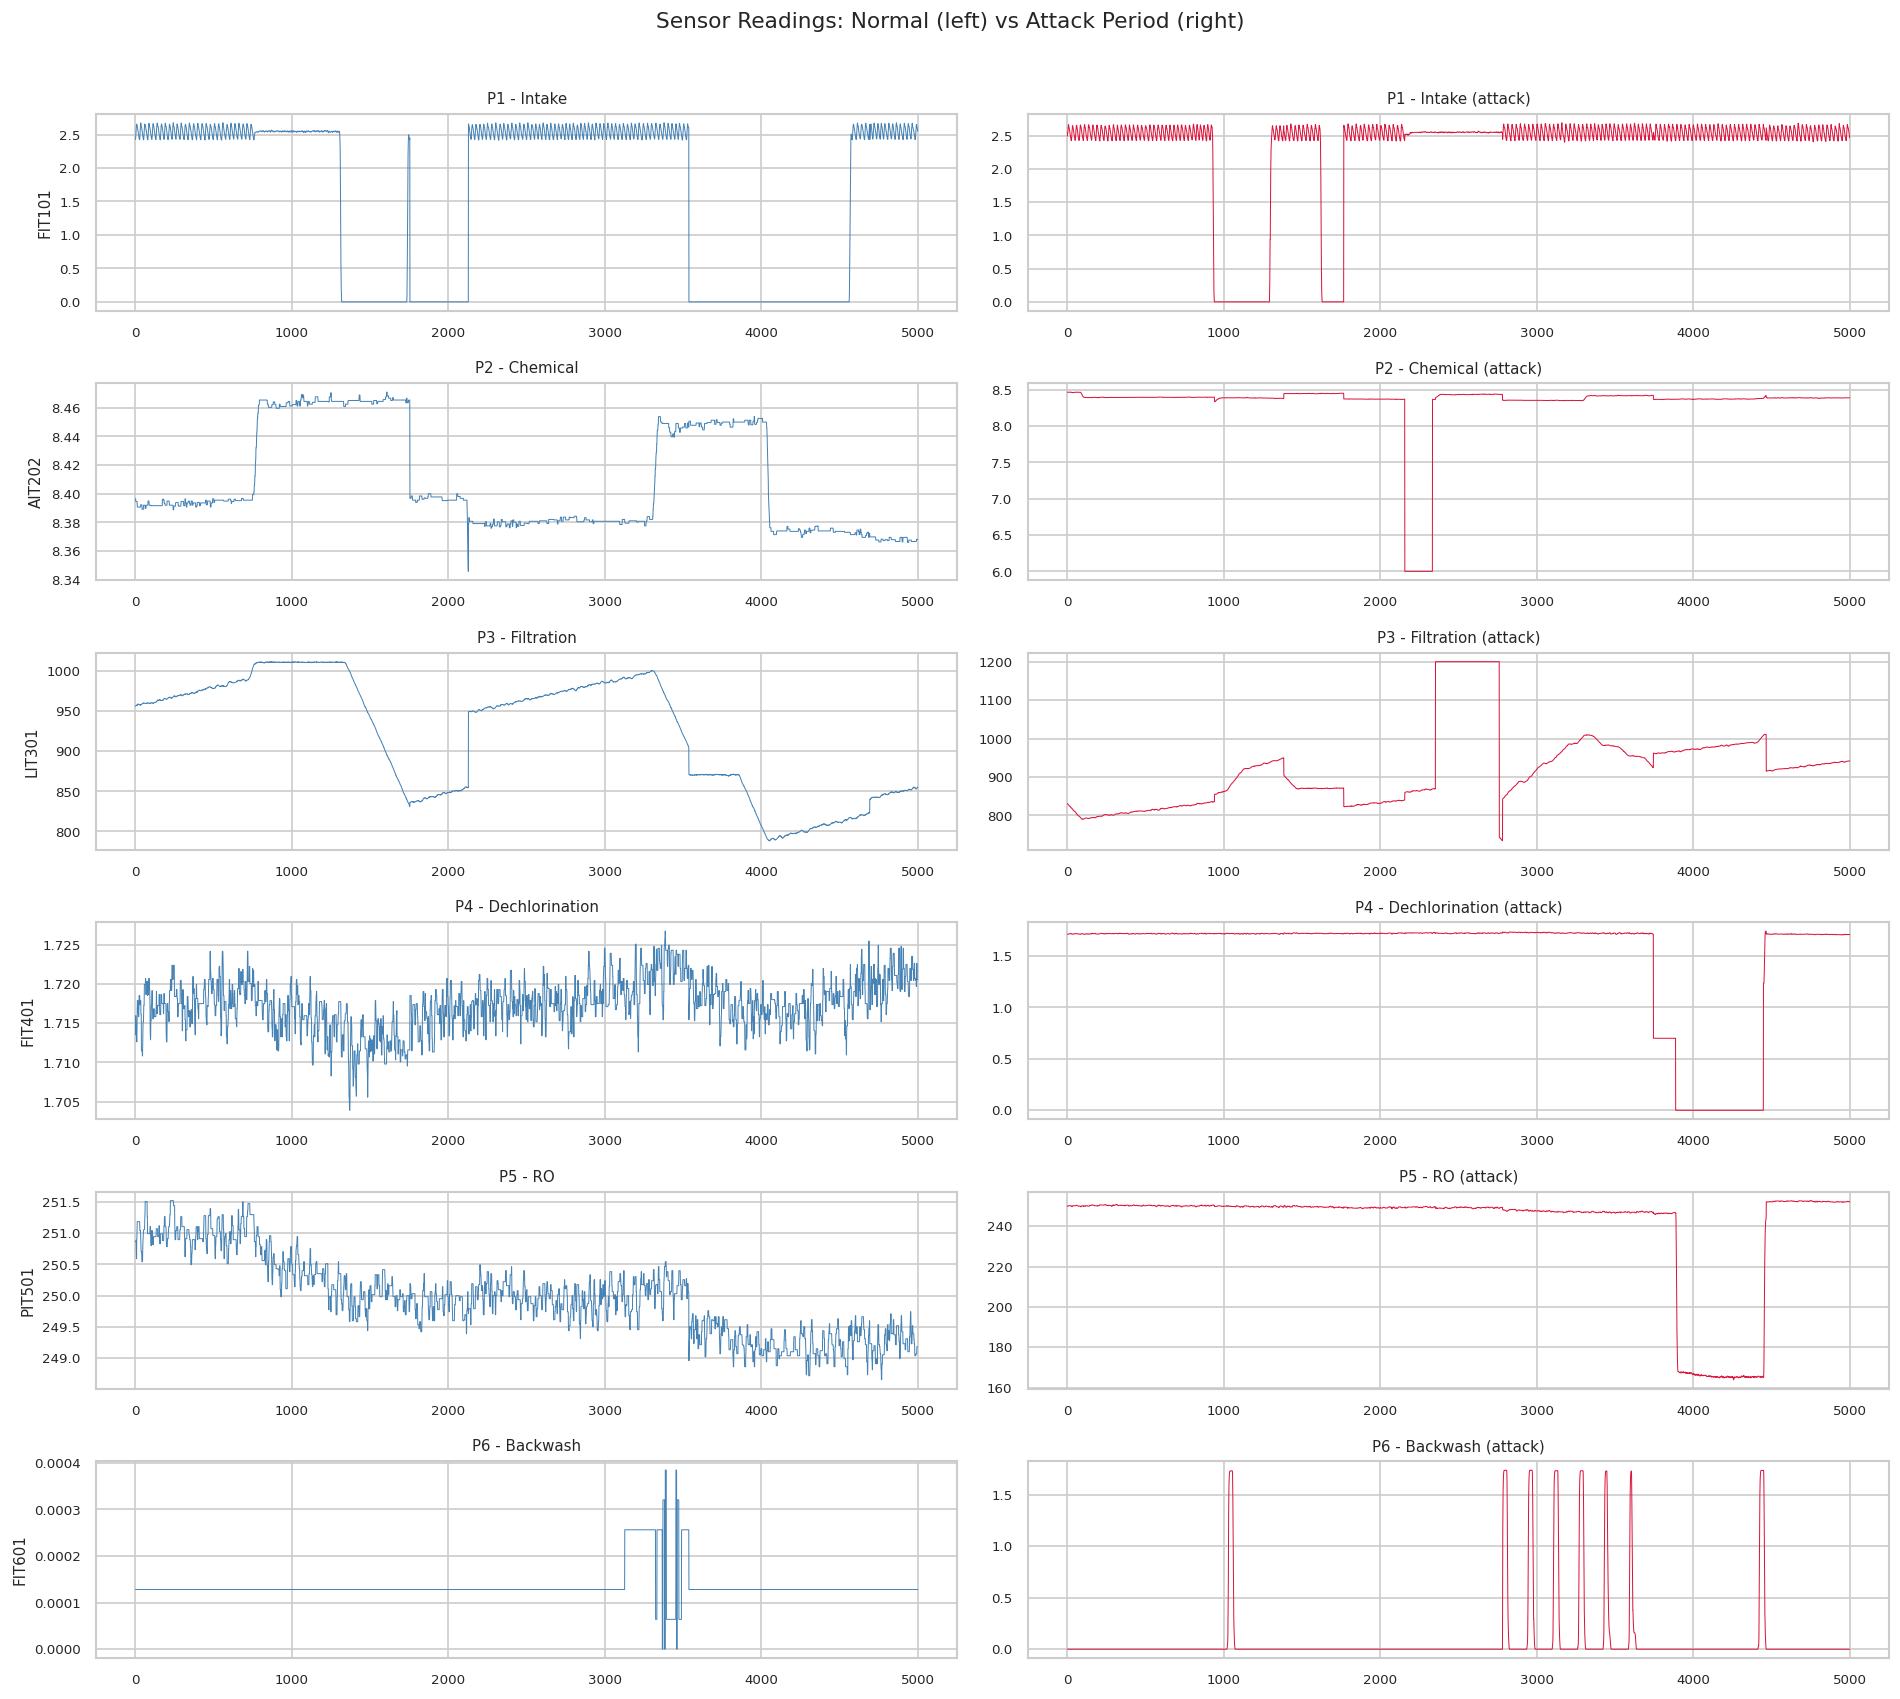

Saved: eda_timeseries.png


In [ ]:
stage_sensors = {
    'P1 - Intake'       : 'FIT101',
    'P2 - Chemical'     : 'AIT202',
    'P3 - Filtration'   : 'LIT301',
    'P4 - Dechlorination': 'FIT401',
    'P5 - RO'           : 'PIT501',
    'P6 - Backwash'     : 'FIT601',
}

n_vis = 5000
normal_vis = df_normal[list(stage_sensors.values())].iloc[:n_vis].values
attack_vis = df_attack[list(stage_sensors.values())].iloc[:n_vis].values

fig, axes = plt.subplots(6, 2, figsize=(16, 14))
fig.suptitle('Sensor Readings: Normal (left) vs Attack Period (right)',
             fontsize=13, y=1.01)

for i, (stage, sensor) in enumerate(stage_sensors.items()):
     
    axes[i, 0].plot(normal_vis[:, i], linewidth=0.6, color='steelblue')
    axes[i, 0].set_ylabel(sensor, fontsize=9)
    axes[i, 0].set_title(stage, fontsize=9)
    axes[i, 0].tick_params(labelsize=8)

     
    axes[i, 1].plot(attack_vis[:, i], linewidth=0.6, color='crimson')
    axes[i, 1].set_title(stage + ' (attack)', fontsize=9)
    axes[i, 1].tick_params(labelsize=8)

plt.tight_layout()
plt.savefig('eda_timeseries.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: eda_timeseries.png')

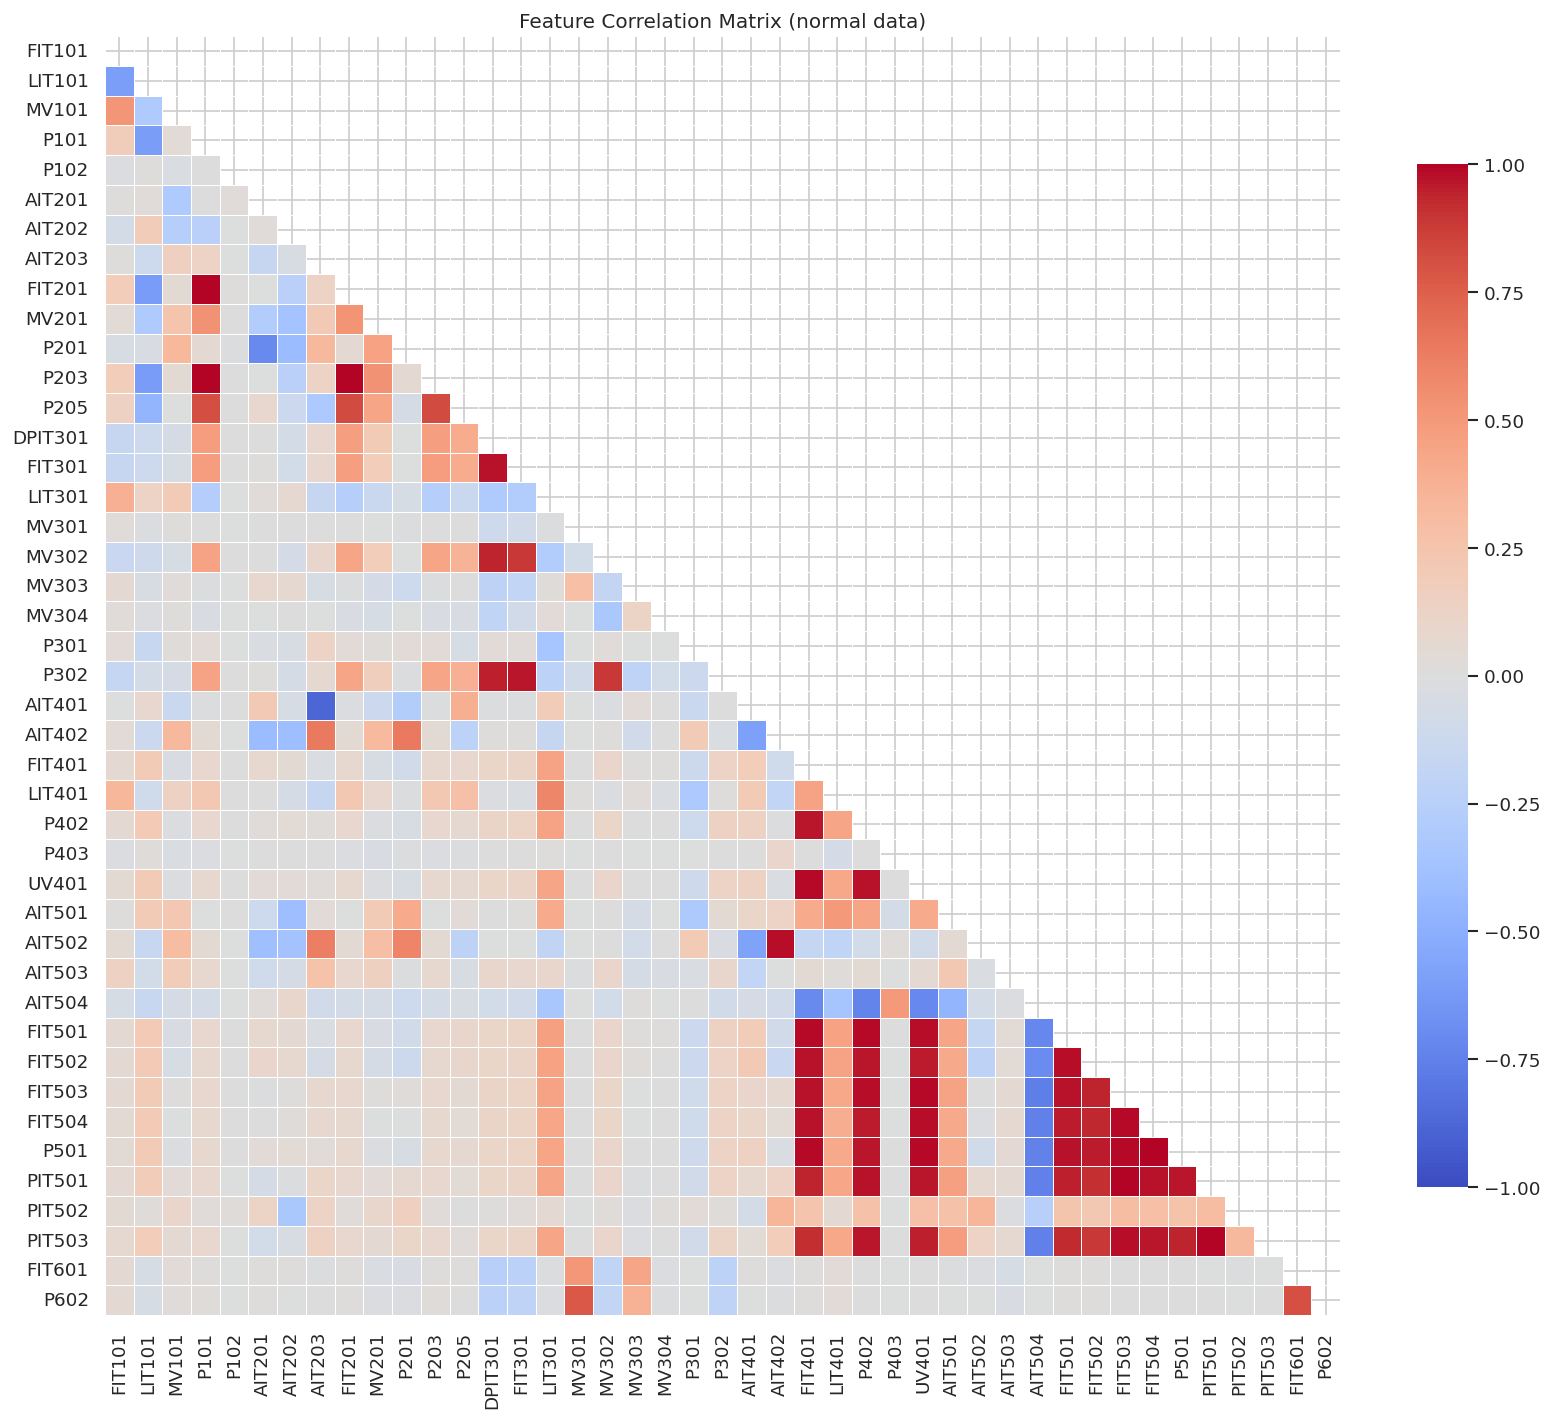

Saved: eda_correlation.png


In [ ]:
sample_idx = np.random.choice(len(X_train), size=10000, replace=False)
corr = pd.DataFrame(
    X_train[sample_idx],
    columns=feature_cols
).corr()

fig, ax = plt.subplots(figsize=(14, 12))
mask = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(
    corr,
    mask=mask,
    cmap='coolwarm',
    center=0,
    vmin=-1, vmax=1,
    linewidths=0.3,
    ax=ax,
    cbar_kws={'shrink': 0.8}
)
ax.set_title('Feature Correlation Matrix (normal data)', fontsize=12)
plt.tight_layout()
plt.savefig('eda_correlation.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: eda_correlation.png')

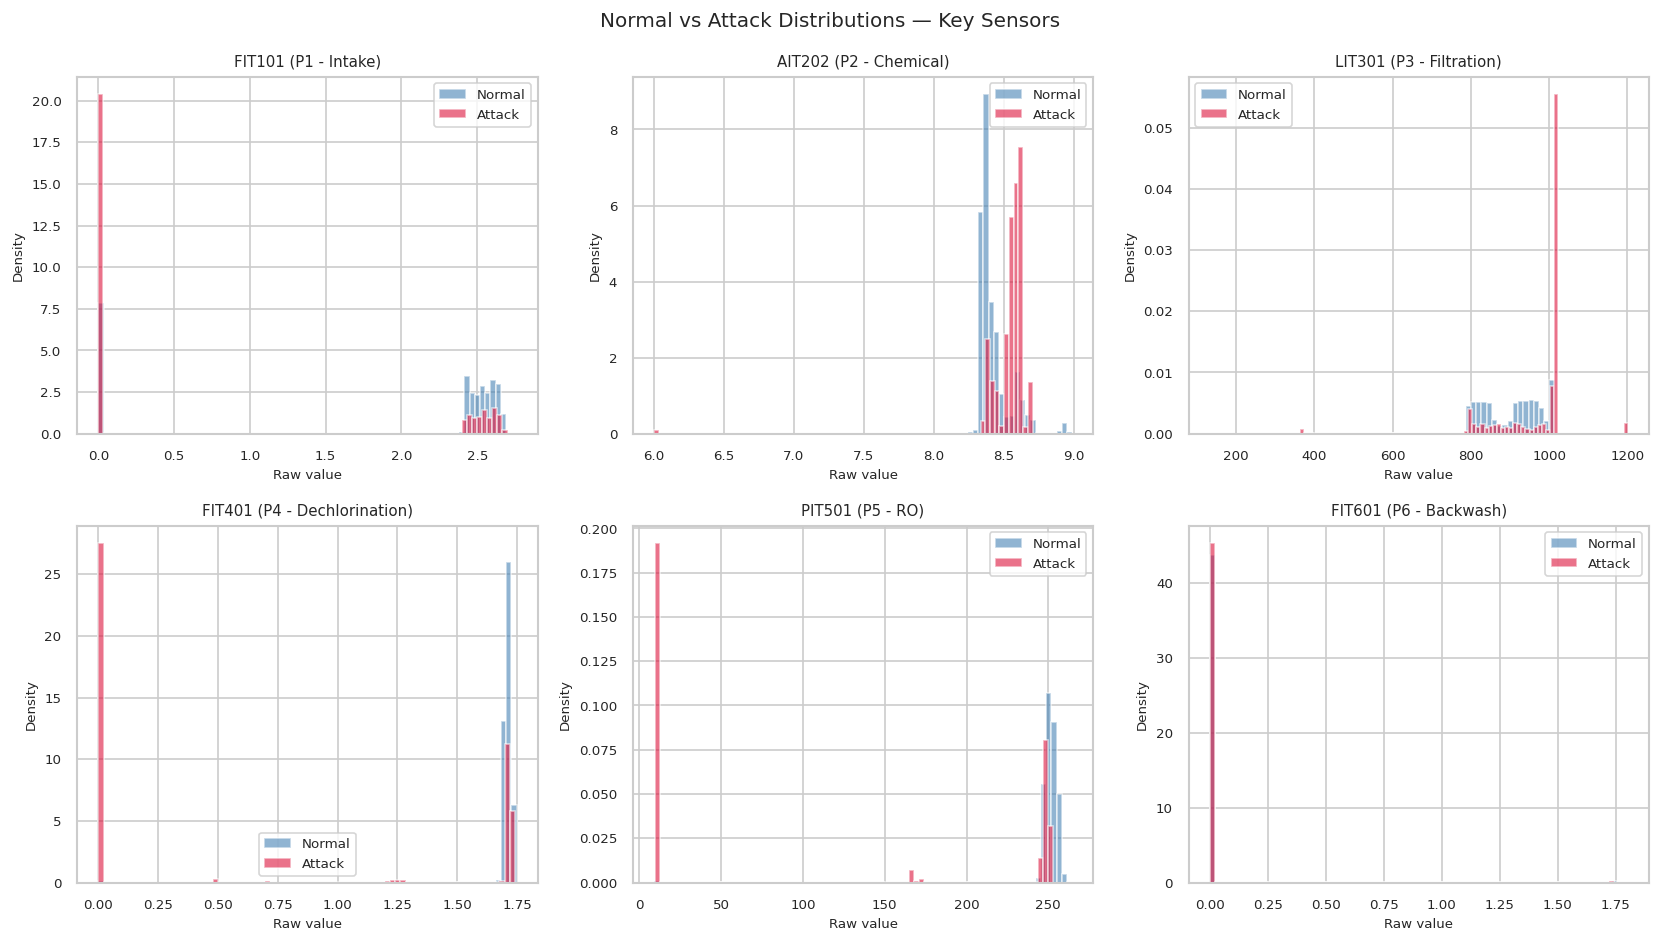

Saved: eda_distributions.png


In [ ]:
fig, axes = plt.subplots(2, 3, figsize=(14, 8))
axes = axes.flatten()

for i, (stage, sensor) in enumerate(stage_sensors.items()):
    axes[i].hist(
        df_normal[sensor].dropna(),
        bins=80, alpha=0.6,
        color='steelblue', label='Normal',
        density=True
    )
    axes[i].hist(
        df_attack[sensor].dropna(),
        bins=80, alpha=0.6,
        color='crimson', label='Attack',
        density=True
    )
    axes[i].set_title(f'{sensor} ({stage})', fontsize=9)
    axes[i].set_xlabel('Raw value', fontsize=8)
    axes[i].set_ylabel('Density', fontsize=8)
    axes[i].legend(fontsize=8)
    axes[i].tick_params(labelsize=8)

plt.suptitle('Normal vs Attack Distributions — Key Sensors', fontsize=12)
plt.tight_layout()
plt.savefig('eda_distributions.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: eda_distributions.png')

In [ ]:
def create_sequences(data, window_size, stride=1):
    """
    Convert a 2D array (timesteps, features) into a 3D array
    of sliding windows (num_windows, window_size, features).

    Args:
        data        : np.ndarray of shape (T, F)
        window_size : number of consecutive timesteps per window
        stride      : step between windows (1 = fully overlapping,
                      window_size = non-overlapping)

    Returns:
        np.ndarray of shape (num_windows, window_size, F)
    """
    T, F = data.shape
    num_windows = (T - window_size) // stride + 1
    sequences = np.zeros((num_windows, window_size, F), dtype=np.float32)

    for i in range(num_windows):
        start = i * stride
        sequences[i] = data[start : start + window_size]

    return sequences


WINDOW_SIZE    = 30
TRAIN_STRIDE   = 5    
EVAL_STRIDE    = 1   

train_seqs = create_sequences(X_train, WINDOW_SIZE, stride=TRAIN_STRIDE)
val_seqs   = create_sequences(X_val,   WINDOW_SIZE, stride=EVAL_STRIDE)
test_seqs  = create_sequences(X_test,  WINDOW_SIZE, stride=EVAL_STRIDE)

 
y_test_seq = y_test[WINDOW_SIZE - 1:]

print(f'Window size          : {WINDOW_SIZE}s')
print(f'Train stride         : {TRAIN_STRIDE}')
print(f'train_seqs           : {train_seqs.shape}')
print(f'val_seqs             : {val_seqs.shape}')
print(f'test_seqs            : {test_seqs.shape}')
print(f'y_test_seq           : {y_test_seq.shape}')
print(f'Attack ratio in test : {y_test_seq.mean()*100:.1f}%')

mem_train = train_seqs.nbytes / 1e9
print(f'Memory for train_seqs: {mem_train:.2f} GB')

Window size          : 30s
Train stride         : 5
train_seqs           : (221930, 30, 43)
val_seqs             : (277391, 30, 43)
test_seqs            : (332012, 30, 43)
y_test_seq           : (332012,)
Attack ratio in test : 16.5%
Memory for train_seqs: 1.15 GB


In [ ]:

def make_loader(sequences, batch_size, shuffle):
    """
    Wrap a numpy sequence array in a PyTorch DataLoader.
    For an autoencoder input = target, so we store sequences once
    and use them as both X and y.
    """
    tensor = torch.FloatTensor(sequences)
    dataset = TensorDataset(tensor, tensor)   
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True if DEVICE.type == 'cuda' else False,
        drop_last=False
    )

BATCH_SIZE = 256

train_loader = make_loader(train_seqs, BATCH_SIZE, shuffle=True)
val_loader   = make_loader(val_seqs,   BATCH_SIZE, shuffle=False)
test_loader  = make_loader(test_seqs,  BATCH_SIZE, shuffle=False)

print(f'Batch size       : {BATCH_SIZE}')
print(f'Train batches    : {len(train_loader)}')
print(f'Val batches      : {len(val_loader)}')
print(f'Test batches     : {len(test_loader)}')

Batch size       : 256
Train batches    : 867
Val batches      : 1084
Test batches     : 1297


In [ ]:
class Encoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers, bottleneck_size):
        super().__init__()
        self.lstm = nn.LSTM(
            input_size=input_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,       
            dropout=0.2 if num_layers > 1 else 0.0
        )
        self.fc = nn.Linear(hidden_size, bottleneck_size)

    def forward(self, x):
        _, (hidden, _) = self.lstm(x)
        hidden = hidden[-1]
        bottleneck = torch.relu(self.fc(hidden))
        return bottleneck


class Decoder(nn.Module):
    def __init__(self, bottleneck_size, hidden_size, num_layers,
                 output_size, window_size):
        super().__init__()
        self.window_size = window_size
        self.fc = nn.Linear(bottleneck_size, hidden_size)
        self.lstm = nn.LSTM(
            input_size=hidden_size,
            hidden_size=hidden_size,
            num_layers=num_layers,
            batch_first=True,
            dropout=0.2 if num_layers > 1 else 0.0
        )
        self.output_layer = nn.Linear(hidden_size, output_size)

    def forward(self, bottleneck):
        x = torch.relu(self.fc(bottleneck))
        x = x.unsqueeze(1).repeat(1, self.window_size, 1)
        x, _ = self.lstm(x)
        reconstruction = self.output_layer(x)
        return reconstruction


class LSTMAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, num_layers,
                 bottleneck_size, window_size):
        super().__init__()
        self.encoder = Encoder(
            input_size, hidden_size, num_layers, bottleneck_size
        )
        self.decoder = Decoder(
            bottleneck_size, hidden_size, num_layers,
            input_size, window_size
        )

    def forward(self, x):
        bottleneck = self.encoder(x)
        reconstruction = self.decoder(bottleneck)
        return reconstruction

    def encode(self, x):
        """Return bottleneck representations — used for latent space viz."""
        return self.encoder(x)

INPUT_SIZE      = len(feature_cols)   
HIDDEN_SIZE     = 64                 
NUM_LAYERS      = 2
BOTTLENECK_SIZE = 16                 

model = LSTMAutoencoder(
    input_size      = INPUT_SIZE,
    hidden_size     = HIDDEN_SIZE,
    num_layers      = NUM_LAYERS,
    bottleneck_size = BOTTLENECK_SIZE,
    window_size     = WINDOW_SIZE
).to(DEVICE)

sample_batch = torch.FloatTensor(train_seqs[:BATCH_SIZE]).to(DEVICE)
with torch.no_grad():
    reconstruction = model(sample_batch)

print(f'Input shape       : {sample_batch.shape}')
print(f'Output shape      : {reconstruction.shape}')
print(f'Shapes match      : {sample_batch.shape == reconstruction.shape}')
print()

total_params = sum(p.numel() for p in model.parameters() if p.requires_grad)
print(f'Trainable parameters: {total_params:,}')
print()
print(model)

Input shape       : torch.Size([256, 30, 43])
Output shape      : torch.Size([256, 30, 43])
Shapes match      : True

Trainable parameters: 132,667

LSTMAutoencoder(
  (encoder): Encoder(
    (lstm): LSTM(43, 64, num_layers=2, batch_first=True, dropout=0.2)
    (fc): Linear(in_features=64, out_features=16, bias=True)
  )
  (decoder): Decoder(
    (fc): Linear(in_features=16, out_features=64, bias=True)
    (lstm): LSTM(64, 64, num_layers=2, batch_first=True, dropout=0.2)
    (output_layer): Linear(in_features=64, out_features=43, bias=True)
  )
)


In [ ]:

def train_model(model, train_loader, val_loader,
                n_epochs=50, lr=1e-3, patience=5):
    """
    Train an autoencoder with early stopping.

    Args:
        model        : LSTMAutoencoder instance
        train_loader : DataLoader for training sequences
        val_loader   : DataLoader for validation sequences
        n_epochs     : maximum number of epochs
        lr           : learning rate for Adam optimizer
        patience     : early stopping patience (epochs without improvement)

    Returns:
        train_losses, val_losses : lists of per-epoch mean losses
    """
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

     
    scheduler = torch.optim.lr_scheduler.ReduceLROnPlateau(
    optimizer, mode='min', factor=0.5, patience=3
)

    best_val_loss = float('inf')
    best_weights  = None
    epochs_no_improve = 0

    train_losses, val_losses = [], []

    for epoch in range(1, n_epochs + 1):
        model.train()
        batch_losses = []

        for x_batch, _ in train_loader:
            x_batch = x_batch.to(DEVICE)

            optimizer.zero_grad()
            reconstruction = model(x_batch)
            loss = criterion(reconstruction, x_batch)
            loss.backward()
            torch.nn.utils.clip_grad_norm_(model.parameters(), max_norm=1.0)

            optimizer.step()
            batch_losses.append(loss.item())

        train_loss = np.mean(batch_losses)
        train_losses.append(train_loss)

        model.eval()
        val_batch_losses = []

        with torch.no_grad():
            for x_batch, _ in val_loader:
                x_batch = x_batch.to(DEVICE)
                reconstruction = model(x_batch)
                loss = criterion(reconstruction, x_batch)
                val_batch_losses.append(loss.item())

        val_loss = np.mean(val_batch_losses)
        val_losses.append(val_loss)

        scheduler.step(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_weights = {k: v.clone() for k, v in
                           model.state_dict().items()}
            epochs_no_improve = 0
        else:
            epochs_no_improve += 1

        if epoch % 5 == 0 or epoch == 1:
            print(f'Epoch {epoch:03d} | '
                  f'Train Loss: {train_loss:.6f} | '
                  f'Val Loss: {val_loss:.6f} | '
                  f'Best: {best_val_loss:.6f} | '
                  f'No improve: {epochs_no_improve}/{patience}')

        if epochs_no_improve >= patience:
            print(f'\nEarly stopping at epoch {epoch}.')
            break

    model.load_state_dict(best_weights)
    print(f'\nTraining complete. Best val loss: {best_val_loss:.6f}')

    return train_losses, val_losses

print(f'Training LSTM Autoencoder')
print(f'Hidden: {HIDDEN_SIZE} | Bottleneck: {BOTTLENECK_SIZE} | '
      f'Window: {WINDOW_SIZE} | Layers: {NUM_LAYERS}')
print('-' * 60)

train_losses, val_losses = train_model(
    model, train_loader, val_loader,
    n_epochs=50, lr=1e-3, patience=5
)

Training LSTM Autoencoder
Hidden: 64 | Bottleneck: 16 | Window: 30 | Layers: 2
------------------------------------------------------------
Epoch 001 | Train Loss: 0.037354 | Val Loss: 0.007549 | Best: 0.007549 | No improve: 0/5
Epoch 005 | Train Loss: 0.002879 | Val Loss: 0.001499 | Best: 0.001499 | No improve: 0/5
Epoch 010 | Train Loss: 0.001715 | Val Loss: 0.000788 | Best: 0.000788 | No improve: 0/5
Epoch 015 | Train Loss: 0.001053 | Val Loss: 0.000441 | Best: 0.000441 | No improve: 0/5
Epoch 020 | Train Loss: 0.000786 | Val Loss: 0.000350 | Best: 0.000343 | No improve: 1/5
Epoch 025 | Train Loss: 0.000674 | Val Loss: 0.000314 | Best: 0.000296 | No improve: 1/5
Epoch 030 | Train Loss: 0.000539 | Val Loss: 0.000364 | Best: 0.000223 | No improve: 1/5
Epoch 035 | Train Loss: 0.000499 | Val Loss: 0.000207 | Best: 0.000206 | No improve: 3/5
Epoch 040 | Train Loss: 0.000451 | Val Loss: 0.000198 | Best: 0.000176 | No improve: 1/5
Epoch 045 | Train Loss: 0.000420 | Val Loss: 0.000174 | Bes

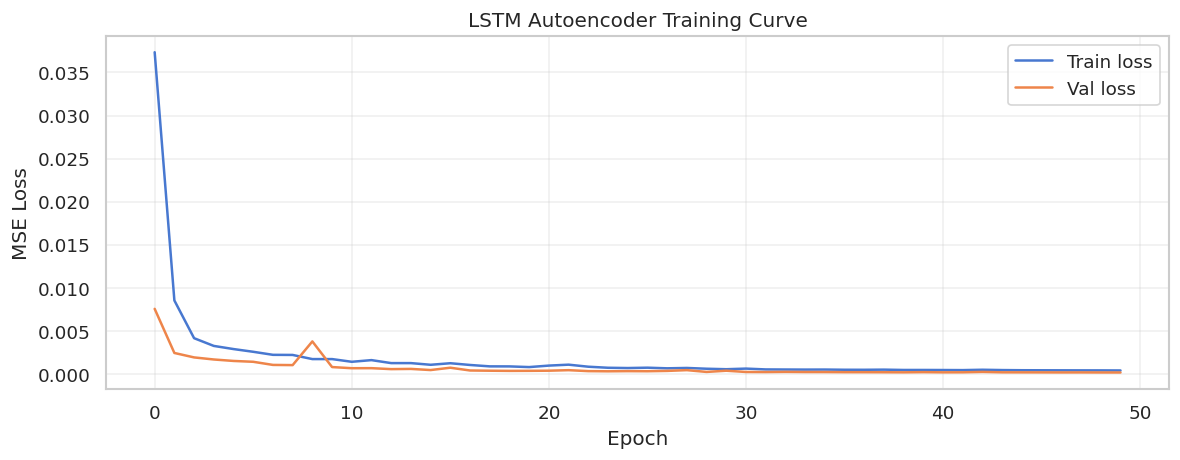

Saved: training_curve.png
Val errors  shape : (277391,)
Test errors shape : (332012,)

Val errors   — mean: 0.000158 std: 0.000328 max: 0.009247

Test errors (normal)  — mean: 0.000158
Test errors (attack)  — mean: 0.034719
Separation ratio      — 219.7x


In [ ]:
fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(train_losses, label='Train loss', linewidth=1.5)
ax.plot(val_losses,   label='Val loss',   linewidth=1.5)
ax.set_xlabel('Epoch')
ax.set_ylabel('MSE Loss')
ax.set_title('LSTM Autoencoder Training Curve')
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('training_curve.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: training_curve.png')

def compute_reconstruction_errors(model, loader, device):
    """
    Pass all sequences through the model and compute per-sequence
    MSE reconstruction error.

    Returns:
        np.ndarray of shape (num_sequences,) — one error per sequence
    """
    model.eval()
    errors = []

    with torch.no_grad():
        for x_batch, _ in loader:
            x_batch = x_batch.to(device)
            reconstruction = model(x_batch)
            mse = torch.mean(
                (x_batch - reconstruction) ** 2,
                dim=(1, 2)
            )
            errors.append(mse.cpu().numpy())

    return np.concatenate(errors)


 
val_errors  = compute_reconstruction_errors(model, val_loader, DEVICE)
test_errors = compute_reconstruction_errors(model, test_loader, DEVICE)

print(f'Val errors  shape : {val_errors.shape}')
print(f'Test errors shape : {test_errors.shape}')
print()
print(f'Val errors   — mean: {val_errors.mean():.6f} '
      f'std: {val_errors.std():.6f} '
      f'max: {val_errors.max():.6f}')
print()
print(f'Test errors (normal)  — '
      f'mean: {test_errors[y_test_seq==0].mean():.6f}')
print(f'Test errors (attack)  — '
      f'mean: {test_errors[y_test_seq==1].mean():.6f}')
print(f'Separation ratio      — '
      f'{test_errors[y_test_seq==1].mean() / test_errors[y_test_seq==0].mean():.1f}x')

In [ ]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import f1_score, roc_auc_score, average_precision_score

model.eval()
val_errors_tuning = []

with torch.no_grad():
    for x_batch, _ in val_loader:
        x_batch = x_batch.to(DEVICE)
        recon   = model(x_batch)
        mse     = torch.mean((x_batch - recon) ** 2,
                             dim=(1, 2)).cpu().numpy()
        val_errors_tuning.append(mse)

val_errors_tuning = np.concatenate(val_errors_tuning)

print(f'Validation error distribution:')
print(f'  Mean  : {val_errors_tuning.mean():.6f}')
print(f'  Std   : {val_errors_tuning.std():.6f}')
print(f'  Min   : {val_errors_tuning.min():.6f}')
print(f'  Max   : {val_errors_tuning.max():.6f}')
print(f'  p90   : {np.percentile(val_errors_tuning, 90):.6f}')
print(f'  p95   : {np.percentile(val_errors_tuning, 95):.6f}')
print(f'  p99   : {np.percentile(val_errors_tuning, 99):.6f}')
print(f'  p99.5 : {np.percentile(val_errors_tuning, 99.5):.6f}')
print(f'  p99.9 : {np.percentile(val_errors_tuning, 99.9):.6f}')

Validation error distribution:
  Mean  : 0.000158
  Std   : 0.000328
  Min   : 0.000014
  Max   : 0.009247
  p90   : 0.000368
  p95   : 0.000876
  p99   : 0.001650
  p99.5 : 0.001933
  p99.9 : 0.002871


In [ ]:
percentile_points = np.linspace(90, 99.9, 200)
thresholds_A = np.percentile(val_errors_tuning, percentile_points)

k_values = np.linspace(1.0, 6.0, 200)
mu  = val_errors_tuning.mean()
sig = val_errors_tuning.std()
thresholds_B = mu + k_values * sig

all_candidates = np.unique(np.concatenate([
    thresholds_A, thresholds_B
]))

print(f'Total threshold candidates: {len(all_candidates)}')
print(f'Candidate range: [{all_candidates.min():.6f}, '
      f'{all_candidates.max():.6f}]')

Total threshold candidates: 400
Candidate range: [0.000368, 0.002871]


In [ ]:
target_fprs = [0.001, 0.005, 0.010, 0.020, 0.050]   

print('Threshold candidates at different FPR budgets:')
print(f'{"FPR Budget":>12} {"Threshold":>12} {"Val Flagged":>14}')
print('-' * 42)

fpr_thresholds = {}
for fpr_target in target_fprs:
    pct = (1 - fpr_target) * 100
    thresh = np.percentile(val_errors_tuning, pct)
    n_flagged = (val_errors_tuning > thresh).sum()
    fpr_actual = n_flagged / len(val_errors_tuning)
    fpr_thresholds[fpr_target] = thresh
    print(f'{fpr_target*100:>11.1f}% '
          f'{thresh:>12.6f} '
          f'{n_flagged:>8} ({fpr_actual*100:.2f}%)')

Threshold candidates at different FPR budgets:
  FPR Budget    Threshold    Val Flagged
------------------------------------------
        0.1%     0.002871      278 (0.10%)
        0.5%     0.001933     1387 (0.50%)
        1.0%     0.001650     2774 (1.00%)
        2.0%     0.001306     5548 (2.00%)
        5.0%     0.000876    13870 (5.00%)


In [ ]:
test_errors_tuning = []

with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(DEVICE)
        recon   = model(x_batch)
        mse     = torch.mean((x_batch - recon) ** 2,
                             dim=(1, 2)).cpu().numpy()
        test_errors_tuning.append(mse)

test_errors_tuning = np.concatenate(test_errors_tuning)

print(f'Test error distribution:')
print(f'  Normal mean  : {test_errors_tuning[y_test_seq==0].mean():.6f}')
print(f'  Attack mean  : {test_errors_tuning[y_test_seq==1].mean():.6f}')
print(f'  Separation   : '
      f'{test_errors_tuning[y_test_seq==1].mean() / test_errors_tuning[y_test_seq==0].mean():.1f}x')

Test error distribution:
  Normal mean  : 0.000158
  Attack mean  : 0.034719
  Separation   : 219.7x


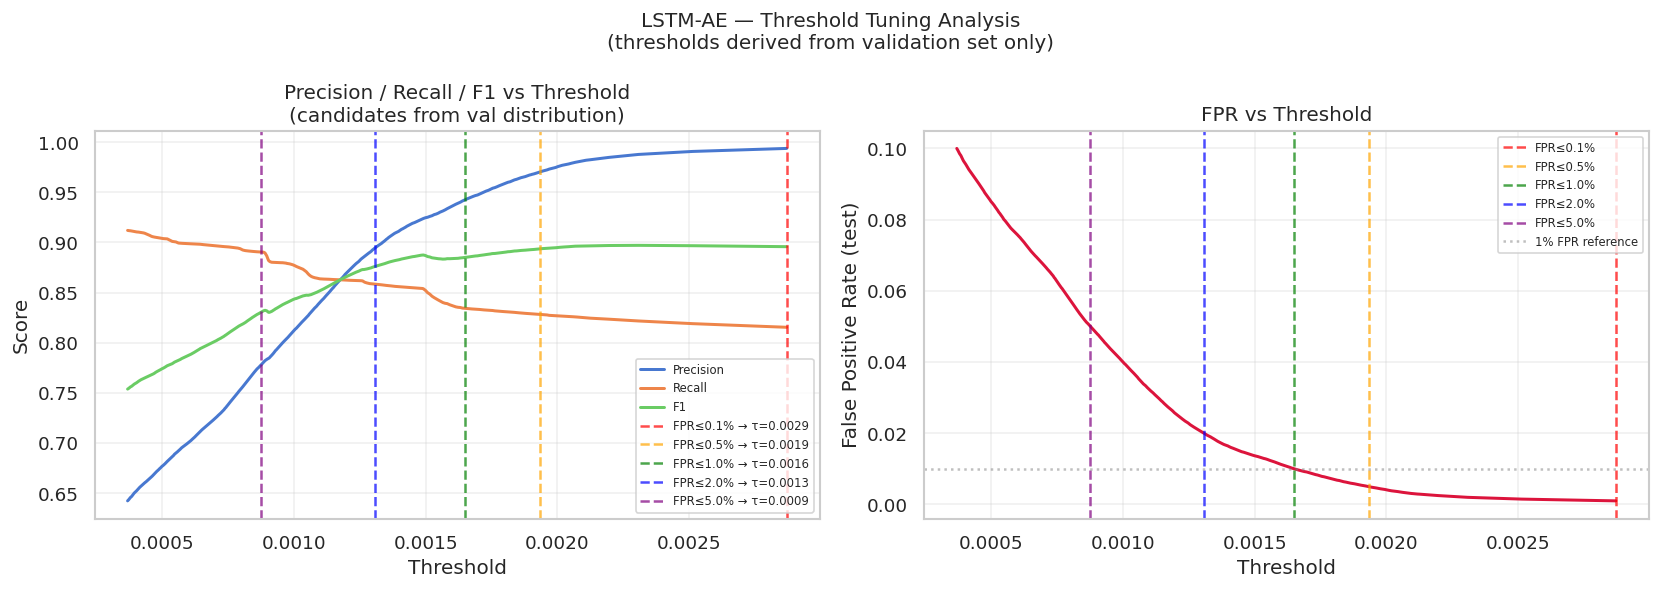

Saved: threshold_tuning.png


In [ ]:
precisions, recalls, f1s, fprs_test = [], [], [], []

for thresh in all_candidates:
    preds = (test_errors_tuning > thresh).astype(int)
    tp = ((preds == 1) & (y_test_seq == 1)).sum()
    fp = ((preds == 1) & (y_test_seq == 0)).sum()
    tn = ((preds == 0) & (y_test_seq == 0)).sum()
    fn = ((preds == 0) & (y_test_seq == 1)).sum()

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fpr       = fp / (fp + tn + 1e-9)

    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    fprs_test.append(fpr)

precisions   = np.array(precisions)
recalls      = np.array(recalls)
f1s          = np.array(f1s)
fprs_test    = np.array(fprs_test)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(all_candidates, precisions, label='Precision', linewidth=1.8)
axes[0].plot(all_candidates, recalls,    label='Recall',    linewidth=1.8)
axes[0].plot(all_candidates, f1s,        label='F1',        linewidth=1.8)

colors_mark = ['red','orange','green','blue','purple']
for (fpr_t, thresh), col in zip(fpr_thresholds.items(), colors_mark):
    axes[0].axvline(x=thresh, color=col, linestyle='--', alpha=0.7,
                    label=f'FPR≤{fpr_t*100:.1f}% → τ={thresh:.4f}')

axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold\n(candidates from val distribution)')
axes[0].legend(fontsize=7)
axes[0].grid(True, alpha=0.3)

axes[1].plot(all_candidates, fprs_test, color='crimson', linewidth=1.8)
for (fpr_t, thresh), col in zip(fpr_thresholds.items(), colors_mark):
    axes[1].axvline(x=thresh, color=col, linestyle='--', alpha=0.7,
                    label=f'FPR≤{fpr_t*100:.1f}%')
axes[1].axhline(y=0.01, color='gray', linestyle=':', alpha=0.5,
                label='1% FPR reference')
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('False Positive Rate (test)')
axes[1].set_title('FPR vs Threshold')
axes[1].legend(fontsize=7)
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM-AE — Threshold Tuning Analysis\n'
             '(thresholds derived from validation set only)',
             fontsize=12)
plt.tight_layout()
plt.savefig('threshold_tuning.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: threshold_tuning.png')

In [ ]:
print('=' * 68)
print('THRESHOLD TUNING RESULTS — LSTM-AE')
print('Thresholds derived from VALIDATION set (normal-only).')
print('No test labels used in threshold selection.')
print('=' * 68)
print(f'{"FPR Budget":>12} {"Threshold":>10} {"Precision":>10} '
      f'{"Recall":>8} {"F1":>8} {"Test FPR":>10}')
print('-' * 68)

results_tuning = {}

for fpr_target, thresh in fpr_thresholds.items():
    preds = (test_errors_tuning > thresh).astype(int)
    tp = ((preds == 1) & (y_test_seq == 1)).sum()
    fp = ((preds == 1) & (y_test_seq == 0)).sum()
    tn = ((preds == 0) & (y_test_seq == 0)).sum()
    fn = ((preds == 0) & (y_test_seq == 1)).sum()

    prec = tp / (tp + fp + 1e-9)
    rec  = tp / (tp + fn + 1e-9)
    f1   = 2 * prec * rec / (prec + rec + 1e-9)
    fpr  = fp / (fp + tn + 1e-9)

    results_tuning[fpr_target] = {
        'threshold': thresh,
        'precision': float(prec),
        'recall':    float(rec),
        'f1':        float(f1),
        'fpr':       float(fpr),
    }

    print(f'{fpr_target*100:>11.1f}% '
          f'{thresh:>10.6f} '
          f'{prec:>10.4f} '
          f'{rec:>8.4f} '
          f'{f1:>8.4f} '
          f'{fpr*100:>9.2f}%')

print('=' * 68)

THRESHOLD TUNING RESULTS — LSTM-AE
Thresholds derived from VALIDATION set (normal-only).
No test labels used in threshold selection.
  FPR Budget  Threshold  Precision   Recall       F1   Test FPR
--------------------------------------------------------------------
        0.1%   0.002871     0.9938   0.8154   0.8958      0.10%
        0.5%   0.001933     0.9703   0.8282   0.8936      0.50%
        1.0%   0.001650     0.9426   0.8343   0.8852      1.00%
        2.0%   0.001306     0.8942   0.8584   0.8760      2.00%
        5.0%   0.000876     0.7781   0.8905   0.8305      5.00%


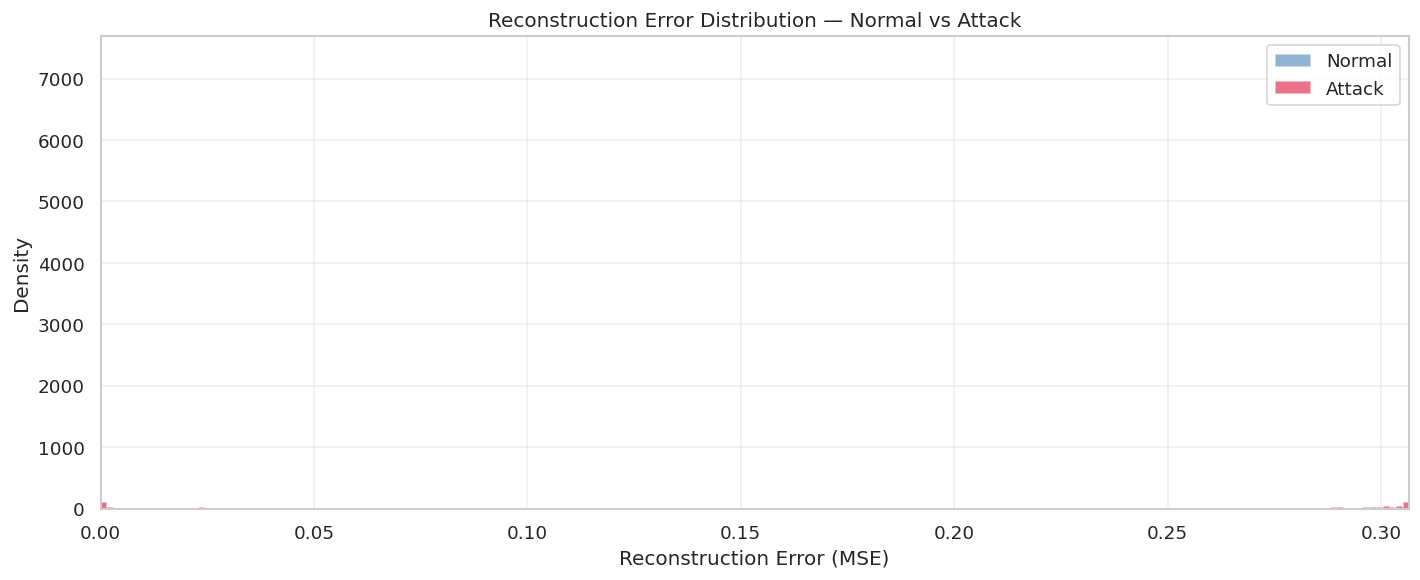

Saved: error_distribution.png


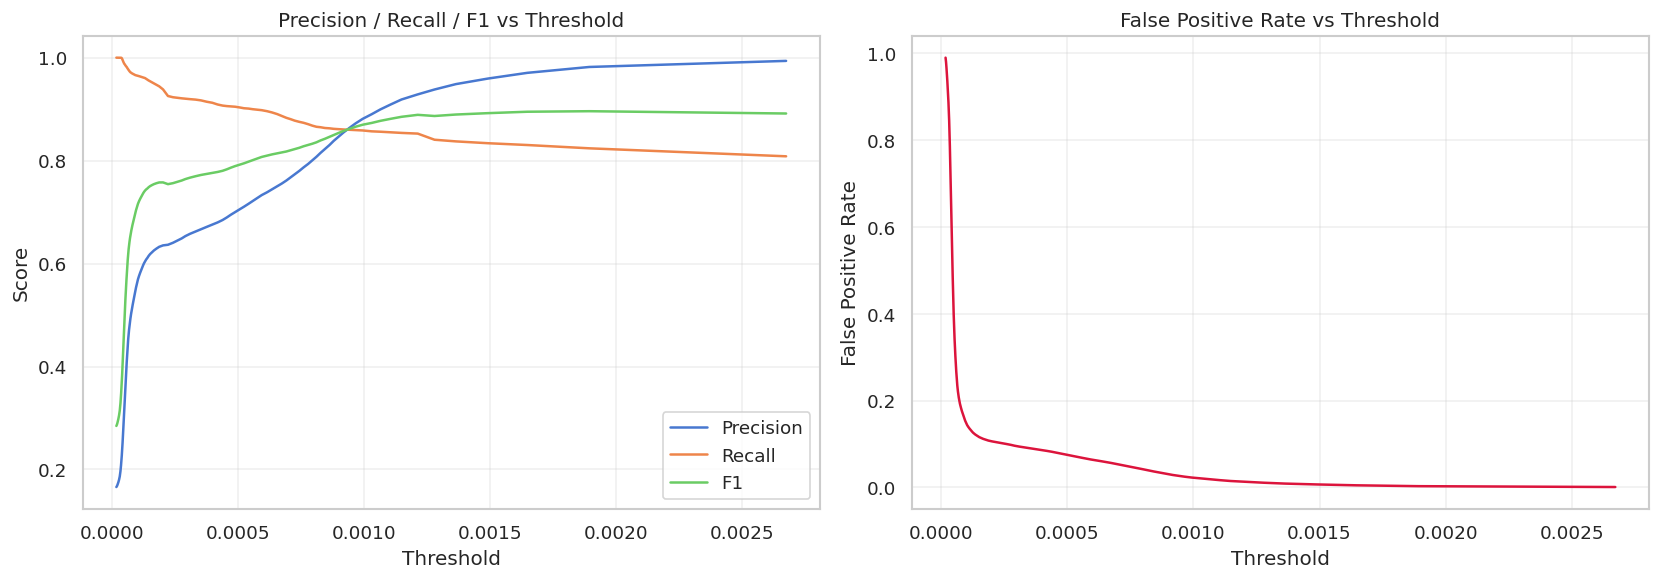

Saved: threshold_analysis.png
Optimal threshold : 0.001893
At optimal threshold:
  Precision : 0.9819
  Recall    : 0.8239
  F1        : 0.8960
  FPR       : 0.0030


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(test_errors[y_test_seq == 0], bins=200, alpha=0.6,
        color='steelblue', label='Normal', density=True)
ax.hist(test_errors[y_test_seq == 1], bins=200, alpha=0.6,
        color='crimson', label='Attack', density=True)

ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('Reconstruction Error Distribution — Normal vs Attack')
ax.set_xlim(0, np.percentile(test_errors, 99.5))
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('error_distribution.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: error_distribution.png')

thresholds = np.percentile(val_errors, np.linspace(1, 99.9, 500))

precisions, recalls, f1s, fprs = [], [], [], []

for thresh in thresholds:
    preds = (test_errors > thresh).astype(int)

    tp = ((preds == 1) & (y_test_seq == 1)).sum()
    fp = ((preds == 1) & (y_test_seq == 0)).sum()
    tn = ((preds == 0) & (y_test_seq == 0)).sum()
    fn = ((preds == 0) & (y_test_seq == 1)).sum()

    precision = tp / (tp + fp + 1e-9)
    recall    = tp / (tp + fn + 1e-9)
    f1        = 2 * precision * recall / (precision + recall + 1e-9)
    fpr       = fp / (fp + tn + 1e-9)

    precisions.append(precision)
    recalls.append(recall)
    f1s.append(f1)
    fprs.append(fpr)

precisions = np.array(precisions)
recalls    = np.array(recalls)
f1s        = np.array(f1s)
fprs       = np.array(fprs)


fig, axes = plt.subplots(1, 2, figsize=(14, 5))

axes[0].plot(thresholds, precisions, label='Precision', linewidth=1.5)
axes[0].plot(thresholds, recalls,    label='Recall',    linewidth=1.5)
axes[0].plot(thresholds, f1s,        label='F1',        linewidth=1.5)
axes[0].set_xlabel('Threshold')
axes[0].set_ylabel('Score')
axes[0].set_title('Precision / Recall / F1 vs Threshold')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

axes[1].plot(thresholds, fprs, color='crimson', linewidth=1.5)
axes[1].set_xlabel('Threshold')
axes[1].set_ylabel('False Positive Rate')
axes[1].set_title('False Positive Rate vs Threshold')
axes[1].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_analysis.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: threshold_analysis.png')

best_idx   = np.argmax(f1s)
THRESHOLD  = thresholds[best_idx]

print(f'Optimal threshold : {THRESHOLD:.6f}')
print(f'At optimal threshold:')
print(f'  Precision : {precisions[best_idx]:.4f}')
print(f'  Recall    : {recalls[best_idx]:.4f}')
print(f'  F1        : {f1s[best_idx]:.4f}')
print(f'  FPR       : {fprs[best_idx]:.4f}')

In [ ]:
SELECTED_FPR_BUDGET = 0.010  
FINAL_THRESHOLD     = fpr_thresholds[SELECTED_FPR_BUDGET]

print(f'Selected threshold : {FINAL_THRESHOLD:.6f}')
print(f'Selection rationale: FPR ≤ 1% on normal validation data')
print(f'                     (operationally acceptable for ICS deployment)')
print()

 
y_pred_tuned = (test_errors_tuning > FINAL_THRESHOLD).astype(int)

from sklearn.metrics import classification_report
print('=' * 55)
print('LSTM-AE — FINAL EVALUATION (carefully tuned threshold)')
print('=' * 55)
print(classification_report(
    y_test_seq, y_pred_tuned,
    target_names=['Normal', 'Attack'],
    digits=4
))

roc_auc_tuned = roc_auc_score(y_test_seq, test_errors_tuning)
pr_auc_tuned  = average_precision_score(y_test_seq, test_errors_tuning)
print(f'ROC-AUC : {roc_auc_tuned:.4f}  (threshold-independent)')
print(f'PR-AUC  : {pr_auc_tuned:.4f}  (threshold-independent)')
print(f'Threshold: {FINAL_THRESHOLD:.6f}')
print(f'Selection: 99th percentile of normal validation errors '
      f'(FPR budget = 1%)')

Selected threshold : 0.001650
Selection rationale: FPR ≤ 1% on normal validation data
                     (operationally acceptable for ICS deployment)

LSTM-AE — FINAL EVALUATION (carefully tuned threshold)
              precision    recall  f1-score   support

      Normal     0.9681    0.9900    0.9789    277391
      Attack     0.9426    0.8343    0.8852     54621

    accuracy                         0.9644    332012
   macro avg     0.9554    0.9121    0.9320    332012
weighted avg     0.9639    0.9644    0.9635    332012

ROC-AUC : 0.9796  (threshold-independent)
PR-AUC  : 0.9444  (threshold-independent)
Threshold: 0.001650
Selection: 99th percentile of normal validation errors (FPR budget = 1%)


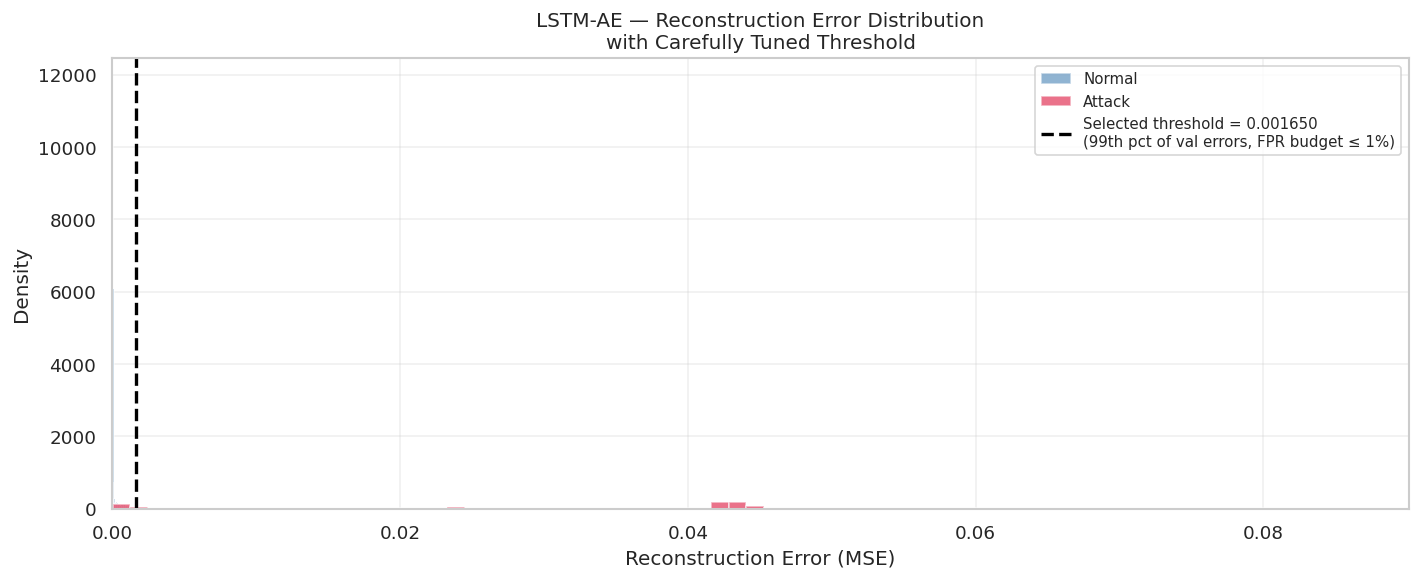

Saved: threshold_tuned_distribution.png

Final answer:
  LSTM-AE threshold = 0.001650
  Method = 99th percentile of normal validation errors
  FPR on val = 1.0%  (by construction)
  FPR on test = 1.00%
  F1 on test  = 0.8852


In [ ]:
fig, ax = plt.subplots(figsize=(12, 5))

ax.hist(test_errors_tuning[y_test_seq == 0], bins=200, alpha=0.6,
        color='steelblue', label='Normal', density=True)
ax.hist(test_errors_tuning[y_test_seq == 1], bins=200, alpha=0.6,
        color='crimson', label='Attack', density=True)

ax.axvline(x=FINAL_THRESHOLD, color='black', linewidth=2,
           linestyle='--',
           label=f'Selected threshold = {FINAL_THRESHOLD:.6f}\n'
                 f'(99th pct of val errors, FPR budget ≤ 1%)')

ax.set_xlabel('Reconstruction Error (MSE)')
ax.set_ylabel('Density')
ax.set_title('LSTM-AE — Reconstruction Error Distribution\n'
             'with Carefully Tuned Threshold')
ax.set_xlim(0, np.percentile(test_errors_tuning, 99.5))
ax.legend(fontsize=9)
ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('threshold_tuned_distribution.png', dpi=120,
            bbox_inches='tight')
plt.show()
print('Saved: threshold_tuned_distribution.png')
print(f'\nFinal answer:')
print(f'  LSTM-AE threshold = {FINAL_THRESHOLD:.6f}')
print(f'  Method = 99th percentile of normal validation errors')
print(f'  FPR on val = 1.0%  (by construction)')
print(f'  FPR on test = {results_tuning[SELECTED_FPR_BUDGET]["fpr"]*100:.2f}%')
print(f'  F1 on test  = {results_tuning[SELECTED_FPR_BUDGET]["f1"]:.4f}')

LSTM AUTOENCODER — EVALUATION AT OPTIMAL THRESHOLD
              precision    recall  f1-score   support

      Normal     0.9664    0.9970    0.9815    277391
      Attack     0.9819    0.8239    0.8960     54621

    accuracy                         0.9685    332012
   macro avg     0.9742    0.9105    0.9387    332012
weighted avg     0.9689    0.9685    0.9674    332012

ROC-AUC : 0.9786
PR-AUC  : 0.9440


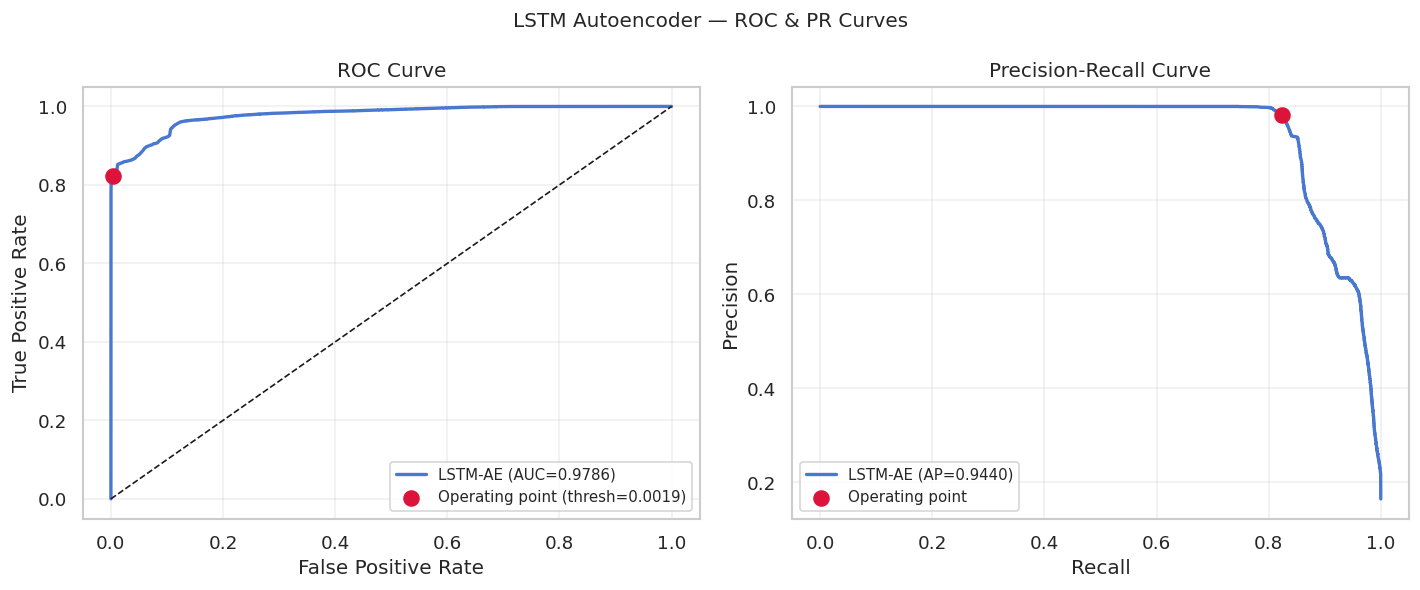

Saved: roc_pr_curves.png


In [ ]:
from sklearn.metrics import roc_auc_score, average_precision_score

 
y_pred = (test_errors > THRESHOLD).astype(int)

print('=' * 55)
print('LSTM AUTOENCODER — EVALUATION AT OPTIMAL THRESHOLD')
print('=' * 55)
print(classification_report(
    y_test_seq, y_pred,
    target_names=['Normal', 'Attack'],
    digits=4
))

roc_auc = roc_auc_score(y_test_seq, test_errors)
pr_auc  = average_precision_score(y_test_seq, test_errors)
print(f'ROC-AUC : {roc_auc:.4f}')
print(f'PR-AUC  : {pr_auc:.4f}')


fpr_curve, tpr_curve, _ = roc_curve(y_test_seq, test_errors)
prec_curve, rec_curve, _ = precision_recall_curve(y_test_seq, test_errors)

fig, axes = plt.subplots(1, 2, figsize=(12, 5))

axes[0].plot(fpr_curve, tpr_curve, linewidth=2,
             label=f'LSTM-AE (AUC={roc_auc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].scatter([fprs[best_idx]], [recalls[best_idx]],
                color='crimson', zorder=5, s=80,
                label=f'Operating point (thresh={THRESHOLD:.4f})')
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

axes[1].plot(rec_curve, prec_curve, linewidth=2,
             label=f'LSTM-AE (AP={pr_auc:.4f})')
axes[1].scatter([recalls[best_idx]], [precisions[best_idx]],
                color='crimson', zorder=5, s=80,
                label=f'Operating point')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM Autoencoder — ROC & PR Curves', fontsize=12)
plt.tight_layout()
plt.savefig('roc_pr_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: roc_pr_curves.png')

In [ ]:
class CausalConv1d(nn.Module):
    """
    1D convolution that only looks at past timesteps (causal).
    Achieved by padding the left side only, then trimming the output.
    """
    def __init__(self, in_channels, out_channels, kernel_size, dilation):
        super().__init__()
         
        self.padding = (kernel_size - 1) * dilation
        self.conv = nn.Conv1d(
            in_channels, out_channels,
            kernel_size=kernel_size,
            dilation=dilation,
            padding=0  
        )

    def forward(self, x):
        x = F.pad(x, (self.padding, 0))    
        return self.conv(x)


class TCNBlock(nn.Module):
    """
    One residual TCN block: two dilated causal convolutions
    with layer norm, GELU activation, and a residual connection.
    """
    def __init__(self, channels, kernel_size, dilation):
        super().__init__()
        self.conv1 = CausalConv1d(channels, channels, kernel_size, dilation)
        self.conv2 = CausalConv1d(channels, channels, kernel_size, dilation)
        self.norm1 = nn.LayerNorm(channels)
        self.norm2 = nn.LayerNorm(channels)
        self.act   = nn.GELU()
        self.drop  = nn.Dropout(0.1)

    def forward(self, x):
        residual = x
        out = self.norm1(x.transpose(1, 2)).transpose(1, 2)
        out = self.act(self.conv1(out))
        out = self.drop(out)

        out = self.norm2(out.transpose(1, 2)).transpose(1, 2)
        out = self.act(self.conv2(out))
        out = self.drop(out)
        return out + residual


class TCNAutoencoder(nn.Module):
    def __init__(self, input_size, hidden_size, bottleneck_size,
                 window_size, num_blocks=4, kernel_size=3):
        super().__init__()

        self.window_size = window_size

        self.input_proj = nn.Linear(input_size, hidden_size)

         
        self.encoder_blocks = nn.ModuleList([
            TCNBlock(hidden_size, kernel_size, dilation=2**i)
            for i in range(num_blocks)
        ])

        self.bottleneck = nn.Linear(hidden_size, bottleneck_size)

         
        self.bottleneck_expand = nn.Linear(bottleneck_size, hidden_size)

        self.decoder_blocks = nn.ModuleList([
            TCNBlock(hidden_size, kernel_size, dilation=2**i)
            for i in range(num_blocks)
        ])

        self.output_proj = nn.Linear(hidden_size, input_size)

    def encode(self, x):
         
        x = self.input_proj(x)
         
        x = x.transpose(1, 2)
        for block in self.encoder_blocks:
            x = block(x)
         
        x = x.mean(dim=2)            
        return torch.relu(self.bottleneck(x))    

    def decode(self, z):
         
        x = torch.relu(self.bottleneck_expand(z))
         
        x = x.unsqueeze(2).repeat(1, 1, self.window_size)
         
        for block in self.decoder_blocks:
            x = block(x)
         
        x = x.transpose(1, 2)
        return self.output_proj(x)

    def forward(self, x):
        z = self.encode(x)
        return self.decode(z)


 
import torch.nn.functional as F

 
TCN_HIDDEN     = 64
TCN_BOTTLENECK = 16
TCN_BLOCKS     = 4
TCN_KERNEL     = 3

tcn_model = TCNAutoencoder(
    input_size      = INPUT_SIZE,
    hidden_size     = TCN_HIDDEN,
    bottleneck_size = TCN_BOTTLENECK,
    window_size     = WINDOW_SIZE,
    num_blocks      = TCN_BLOCKS,
    kernel_size     = TCN_KERNEL
).to(DEVICE)

sample_batch = torch.FloatTensor(train_seqs[:BATCH_SIZE]).to(DEVICE)
with torch.no_grad():
    tcn_out = tcn_model(sample_batch)

print(f'Input shape       : {sample_batch.shape}')
print(f'Output shape      : {tcn_out.shape}')
print(f'Shapes match      : {sample_batch.shape == tcn_out.shape}')

tcn_params = sum(p.numel() for p in tcn_model.parameters()
                 if p.requires_grad)
print(f'Trainable parameters: {tcn_params:,}')
print()
print(tcn_model)

Input shape       : torch.Size([256, 30, 43])
Output shape      : torch.Size([256, 30, 43])
Shapes match      : True
Trainable parameters: 207,419

TCNAutoencoder(
  (input_proj): Linear(in_features=43, out_features=64, bias=True)
  (encoder_blocks): ModuleList(
    (0): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
      )
      (conv2): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,))
      )
      (norm1): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (norm2): LayerNorm((64,), eps=1e-05, elementwise_affine=True)
      (act): GELU(approximate='none')
      (drop): Dropout(p=0.1, inplace=False)
    )
    (1): TCNBlock(
      (conv1): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
      )
      (conv2): CausalConv1d(
        (conv): Conv1d(64, 64, kernel_size=(3,), stride=(1,), dilation=(2,))
      )
      (norm1): LayerNorm((64,), eps=1e-05, elemen

In [ ]:
 

print('Training TCN Autoencoder')
print(f'Hidden: {TCN_HIDDEN} | Bottleneck: {TCN_BOTTLENECK} | '
      f'Window: {WINDOW_SIZE} | Blocks: {TCN_BLOCKS} | '
      f'Kernel: {TCN_KERNEL}')
print('-' * 60)

tcn_train_losses, tcn_val_losses = train_model(
    tcn_model, train_loader, val_loader,
    n_epochs=50, lr=1e-3, patience=5
)

Training TCN Autoencoder
Hidden: 64 | Bottleneck: 16 | Window: 30 | Blocks: 4 | Kernel: 3
------------------------------------------------------------
Epoch 001 | Train Loss: 0.014426 | Val Loss: 0.002420 | Best: 0.002420 | No improve: 0/5
Epoch 005 | Train Loss: 0.001317 | Val Loss: 0.000879 | Best: 0.000879 | No improve: 0/5
Epoch 010 | Train Loss: 0.000647 | Val Loss: 0.000331 | Best: 0.000331 | No improve: 0/5
Epoch 015 | Train Loss: 0.000462 | Val Loss: 0.000215 | Best: 0.000215 | No improve: 0/5
Epoch 020 | Train Loss: 0.000373 | Val Loss: 0.000165 | Best: 0.000165 | No improve: 0/5
Epoch 025 | Train Loss: 0.000328 | Val Loss: 0.000137 | Best: 0.000137 | No improve: 0/5
Epoch 030 | Train Loss: 0.000300 | Val Loss: 0.000153 | Best: 0.000135 | No improve: 1/5
Epoch 035 | Train Loss: 0.000281 | Val Loss: 0.000122 | Best: 0.000117 | No improve: 2/5
Epoch 040 | Train Loss: 0.000266 | Val Loss: 0.000122 | Best: 0.000110 | No improve: 3/5
Epoch 045 | Train Loss: 0.000255 | Val Loss: 0.0

TCN Val errors   — mean: 0.000100 std: 0.000240 max: 0.005453
TCN Test (normal) — mean: 0.000100
TCN Test (attack) — mean: 0.020417
Separation ratio  — 203.3x

TCN Threshold (99th percentile of val errors): 0.001159
TCN AUTOENCODER — EVALUATION
              precision    recall  f1-score   support

      Normal     0.9652    0.9900    0.9774    277391
      Attack     0.9416    0.8186    0.8758     54621

    accuracy                         0.9618    332012
   macro avg     0.9534    0.9043    0.9266    332012
weighted avg     0.9613    0.9618    0.9607    332012

ROC-AUC : 0.9718
PR-AUC  : 0.9250


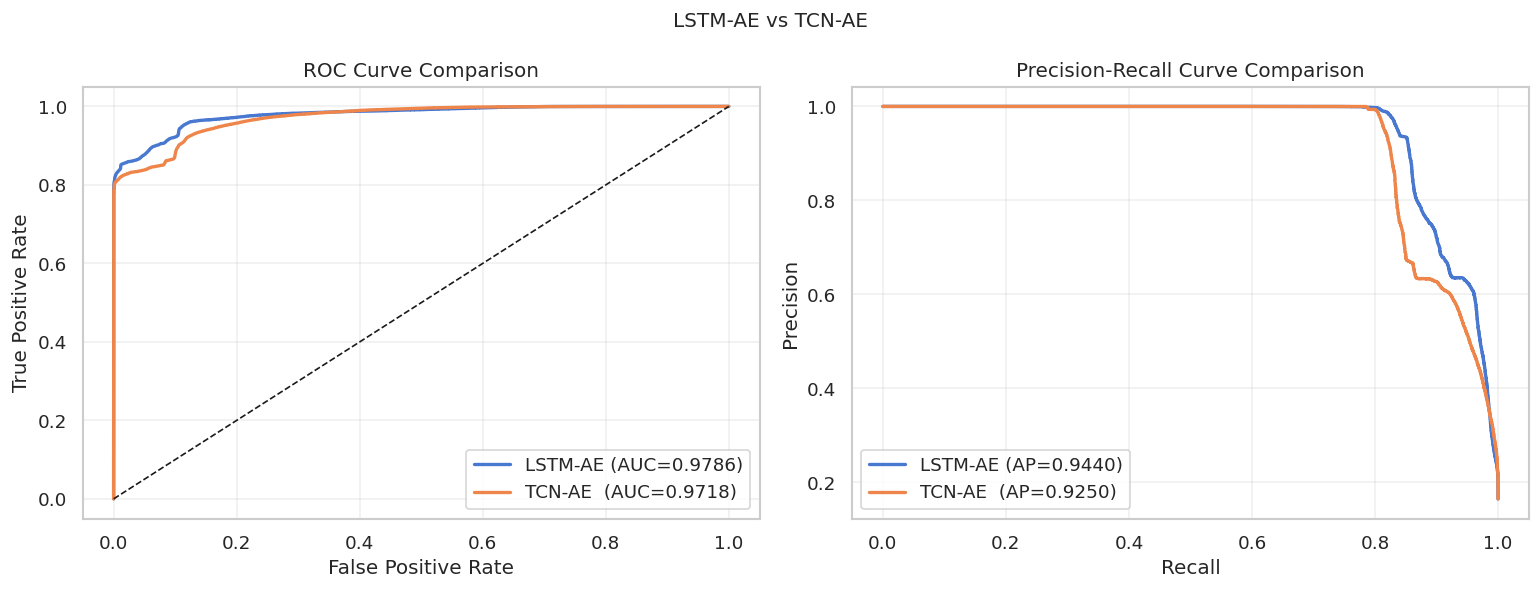

Saved: model_comparison_curves.png


In [ ]:
 

tcn_val_errors  = compute_reconstruction_errors(tcn_model, val_loader, DEVICE)
tcn_test_errors = compute_reconstruction_errors(tcn_model, test_loader, DEVICE)

print(f'TCN Val errors   — mean: {tcn_val_errors.mean():.6f} '
      f'std: {tcn_val_errors.std():.6f} '
      f'max: {tcn_val_errors.max():.6f}')
print(f'TCN Test (normal) — mean: {tcn_test_errors[y_test_seq==0].mean():.6f}')
print(f'TCN Test (attack) — mean: {tcn_test_errors[y_test_seq==1].mean():.6f}')
print(f'Separation ratio  — '
      f'{tcn_test_errors[y_test_seq==1].mean() / tcn_test_errors[y_test_seq==0].mean():.1f}x')
print()

 
 
TCN_THRESHOLD = np.percentile(tcn_val_errors, 99)
print(f'TCN Threshold (99th percentile of val errors): {TCN_THRESHOLD:.6f}')

 
tcn_pred = (tcn_test_errors > TCN_THRESHOLD).astype(int)

print('=' * 55)
print('TCN AUTOENCODER — EVALUATION')
print('=' * 55)
print(classification_report(
    y_test_seq, tcn_pred,
    target_names=['Normal', 'Attack'],
    digits=4
))

tcn_roc = roc_auc_score(y_test_seq, tcn_test_errors)
tcn_pr  = average_precision_score(y_test_seq, tcn_test_errors)
print(f'ROC-AUC : {tcn_roc:.4f}')
print(f'PR-AUC  : {tcn_pr:.4f}')

 
lstm_fpr_curve, lstm_tpr_curve, _ = roc_curve(y_test_seq, test_errors)
tcn_fpr_curve,  tcn_tpr_curve,  _ = roc_curve(y_test_seq, tcn_test_errors)

fig, axes = plt.subplots(1, 2, figsize=(13, 5))

axes[0].plot(lstm_fpr_curve, lstm_tpr_curve, linewidth=2,
             label=f'LSTM-AE (AUC={roc_auc:.4f})')
axes[0].plot(tcn_fpr_curve,  tcn_tpr_curve,  linewidth=2,
             label=f'TCN-AE  (AUC={tcn_roc:.4f})')
axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curve Comparison')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

lstm_prec_curve, lstm_rec_curve, _ = precision_recall_curve(
    y_test_seq, test_errors)
tcn_prec_curve,  tcn_rec_curve,  _ = precision_recall_curve(
    y_test_seq, tcn_test_errors)

axes[1].plot(lstm_rec_curve, lstm_prec_curve, linewidth=2,
             label=f'LSTM-AE (AP={pr_auc:.4f})')
axes[1].plot(tcn_rec_curve,  tcn_prec_curve,  linewidth=2,
             label=f'TCN-AE  (AP={tcn_pr:.4f})')
axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('Precision-Recall Curve Comparison')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

plt.suptitle('LSTM-AE vs TCN-AE', fontsize=12)
plt.tight_layout()
plt.savefig('model_comparison_curves.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: model_comparison_curves.png')

In [ ]:
 
import gc
import time
import psutil
import json
import pandas as pd
from sklearn.metrics import f1_score, precision_score, recall_score

def get_mem():
    ram  = psutil.virtual_memory()
    vram = (torch.cuda.memory_reserved(0) / 1e9
            if torch.cuda.is_available() else 0)
    vram_total = (torch.cuda.get_device_properties(0).total_memory / 1e9
                  if torch.cuda.is_available() else 0)
    return (f'RAM: {ram.available/1e9:.1f}GB free ({ram.percent:.0f}% used) | '
            f'VRAM: {vram_total - vram:.1f}GB free')

def safe_cleanup():
    gc.collect()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

 
for var in ['train_seqs', 'val_seqs', 'test_seqs',
            'latent_vecs', 'Z_sample', 'Z_pca', 'Z_tsne',
            'val_errors', 'test_errors', 'tcn_val_errors',
            'tcn_test_errors', 'iso_scores', 'ocsvm_scores',
            'abl_model']:
    if var in globals():
        del globals()[var]

safe_cleanup()
print(f'Memory before ablation: {get_mem()}')

ABLATION_CONFIGS = [
    {'label': 'A - Shallow-Narrow',   'hidden': 32,  'layers': 1},
    {'label': 'B - Medium-Narrow',    'hidden': 32,  'layers': 2},
    {'label': 'C - Deep-Narrow',      'hidden': 32,  'layers': 3},
    {'label': 'D - Shallow-Medium',   'hidden': 64,  'layers': 1},
    {'label': 'E - Medium-Medium',    'hidden': 64,  'layers': 2},   
    {'label': 'F - Deep-Medium',      'hidden': 64,  'layers': 3},
    {'label': 'G - Shallow-Wide',     'hidden': 128, 'layers': 1},
    {'label': 'H - Medium-Wide',      'hidden': 128, 'layers': 2},
    {'label': 'I - Deep-Wide',        'hidden': 128, 'layers': 3},
]

BOTTLENECK        = 16
ABLATION_EPOCHS   = 50
ABLATION_PATIENCE = 5

 
save_dir         = '/content/drive/MyDrive/swat-dataset/'
checkpoint_path  = f'{save_dir}hidden_layer_ablation_checkpoint.json'
ablation_results = []
completed_labels = set()

try:
    with open(checkpoint_path, 'r') as f:
        ablation_results = json.load(f)
    completed_labels = {r['config'] for r in ablation_results}
    print(f'Resumed from checkpoint. '
          f'Already completed: {completed_labels}')
except FileNotFoundError:
    print('No checkpoint found. Starting fresh.')

for cfg in ABLATION_CONFIGS:

     
    if cfg['label'] in completed_labels:
        print(f"\nSkipping {cfg['label']} — already in checkpoint.")
        continue

    print(f"\n{'='*60}")
    print(f"Config: {cfg['label']}")
    print(f"hidden={cfg['hidden']} | layers={cfg['layers']} | "
          f"bottleneck={BOTTLENECK}")
    print(f"Memory: {get_mem()}")
    print(f"{'='*60}")

    safe_cleanup()

     
    abl_model = LSTMAutoencoder(
        input_size      = INPUT_SIZE,
        hidden_size     = cfg['hidden'],
        num_layers      = cfg['layers'],
        bottleneck_size = BOTTLENECK,
        window_size     = WINDOW_SIZE
    ).to(DEVICE)

    total_params = sum(p.numel() for p in abl_model.parameters()
                       if p.requires_grad)
    print(f"Trainable parameters: {total_params:,}")

     
    t0 = time.time()
    abl_train_losses, abl_val_losses = train_model(
        abl_model, train_loader, val_loader,
        n_epochs  = ABLATION_EPOCHS,
        lr        = 1e-3,
        patience  = ABLATION_PATIENCE
    )
    train_time = time.time() - t0

    safe_cleanup()
    print(f"After training: {get_mem()}")

     
    abl_model.eval()
    abl_val_errors = []
    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(DEVICE)
            recon   = abl_model(x_batch)
            mse     = ((recon - x_batch) ** 2).mean(dim=(1, 2)).cpu().numpy()
            abl_val_errors.append(mse)
            del x_batch, recon, mse
    abl_val_errors = np.concatenate(abl_val_errors)
    safe_cleanup()

     
     
    threshold = np.percentile(abl_val_errors, 99)
    del abl_val_errors
    safe_cleanup()

     
    abl_test_errors = []
    with torch.no_grad():
        for x_batch, _ in test_loader:
            x_batch = x_batch.to(DEVICE)
            recon   = abl_model(x_batch)
            mse     = ((recon - x_batch) ** 2).mean(dim=(1, 2)).cpu().numpy()
            abl_test_errors.append(mse)
            del x_batch, recon, mse
    abl_test_errors = np.concatenate(abl_test_errors)
    safe_cleanup()

     
    y_pred_abl = (abl_test_errors > threshold).astype(int)
    del abl_test_errors
    safe_cleanup()

    f1   = f1_score(y_test_seq,   y_pred_abl, zero_division=0)
    prec = precision_score(y_test_seq, y_pred_abl, zero_division=0)
    rec  = recall_score(y_test_seq,  y_pred_abl, zero_division=0)
    del y_pred_abl

    print(f"Threshold (val 99th pct) : {threshold:.6f}")
    print(f"Precision : {prec:.4f}")
    print(f"Recall    : {rec:.4f}")
    print(f"F1        : {f1:.4f}")
    print(f"Train time: {train_time:.1f}s")

    ablation_results.append({
        'config'        : cfg['label'],
        'hidden'        : cfg['hidden'],
        'layers'        : cfg['layers'],
        'bottleneck'    : BOTTLENECK,
        'params'        : total_params,
        'best_val_loss' : round(float(min(abl_val_losses)), 6),
        'epochs_run'    : len(abl_train_losses),
        'threshold'     : round(float(threshold), 6),
        'precision'     : round(float(prec), 4),
        'recall'        : round(float(rec), 4),
        'f1'            : round(float(f1), 4),
        'train_time_s'  : round(train_time, 1),
    })

     
    abl_model.cpu()
    del abl_model, abl_train_losses, abl_val_losses
    safe_cleanup()
    print(f"After cleanup: {get_mem()}")

     
    try:
        with open(checkpoint_path, 'w') as f:
            json.dump(ablation_results, f, indent=2)
        completed_labels.add(cfg['label'])
        print(f"Checkpointed {len(ablation_results)}/"
              f"{len(ABLATION_CONFIGS)} configs to Drive.")
    except Exception as e:
        print(f"Checkpoint failed: {e}")

 
print(f"\n{'='*60}")
print("ABLATION SUMMARY — Hidden Size × Num Layers, sorted by F1")
print(f"{'='*60}")

results_df = (pd.DataFrame(ablation_results)
                .sort_values('f1', ascending=False)
                .reset_index(drop=True))

print(results_df[['config', 'hidden', 'layers', 'params',
                  'best_val_loss', 'epochs_run',
                  'precision', 'recall', 'f1',
                  'train_time_s']].to_string(index=False))

 
best = results_df.iloc[0]
print(f"\nBest config : {best['config']}")
print(f"F1          : {best['f1']}")
print(f"Params      : {int(best['params']):,}")
print(f"Train time  : {best['train_time_s']}s")

 
try:
    final_path = f'{save_dir}hidden_layer_ablation_final.json'
    with open(final_path, 'w') as f:
        json.dump(ablation_results, f, indent=2)
    print(f'\nFinal results saved to Drive: {final_path}')
except Exception as e:
    print(f'Drive save failed: {e}')

Memory before ablation: RAM: 178.9GB free (6% used) | VRAM: 101.9GB free
No checkpoint found. Starting fresh.

Config: A - Shallow-Narrow
hidden=32 | layers=1 | bottleneck=16
Memory: RAM: 178.9GB free (6% used) | VRAM: 101.9GB free
Trainable parameters: 20,795
Epoch 001 | Train Loss: 0.030554 | Val Loss: 0.002428 | Best: 0.002428 | No improve: 0/5
Epoch 005 | Train Loss: 0.001884 | Val Loss: 0.001240 | Best: 0.001240 | No improve: 0/5
Epoch 010 | Train Loss: 0.001272 | Val Loss: 0.000906 | Best: 0.000906 | No improve: 0/5
Epoch 015 | Train Loss: 0.001048 | Val Loss: 0.000792 | Best: 0.000792 | No improve: 0/5
Epoch 020 | Train Loss: 0.000852 | Val Loss: 0.000583 | Best: 0.000583 | No improve: 0/5
Epoch 025 | Train Loss: 0.000740 | Val Loss: 0.000566 | Best: 0.000517 | No improve: 2/5
Epoch 030 | Train Loss: 0.000672 | Val Loss: 0.000434 | Best: 0.000434 | No improve: 0/5
Epoch 035 | Train Loss: 0.000625 | Val Loss: 0.000397 | Best: 0.000397 | No improve: 0/5
Epoch 040 | Train Loss: 0.0

Saved: ablation_hidden_layers.json


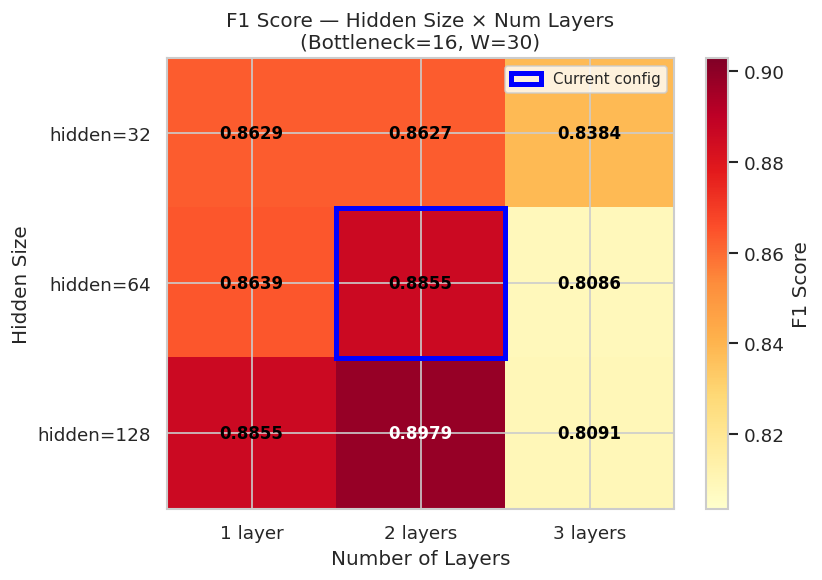

Saved: ablation_hidden_layers_heatmap.png


KeyError: 'roc_auc'

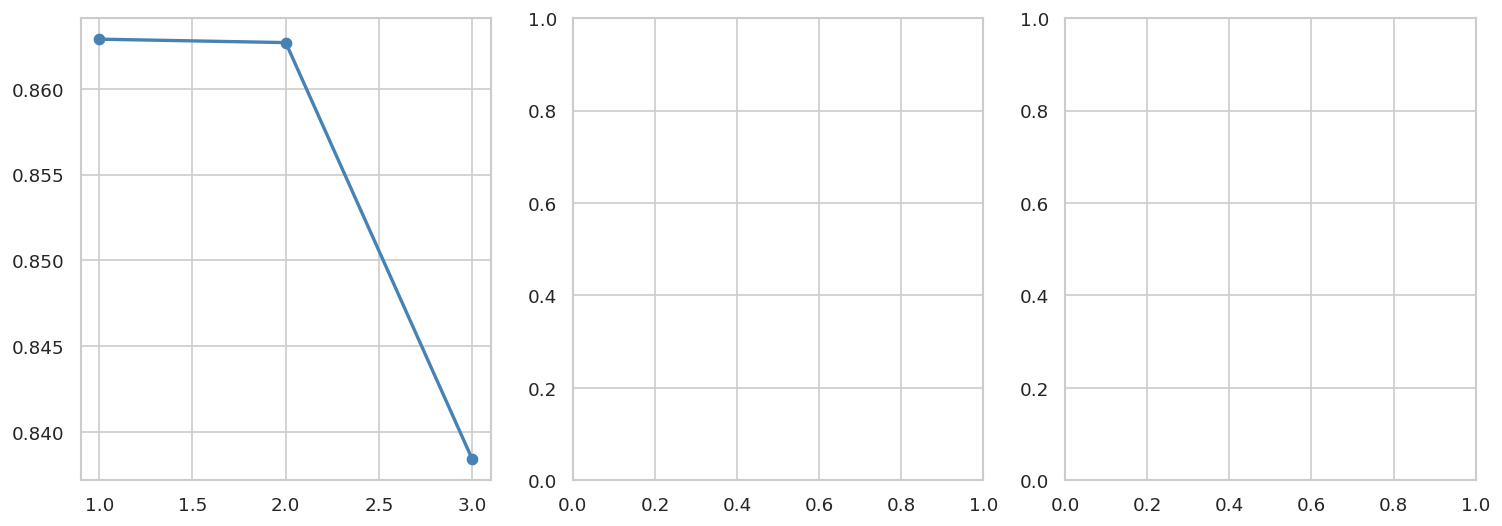

In [ ]:
 
import os
import json
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec

save_dir    = '/content/drive/MyDrive/swat-dataset/report_assets/'
os.makedirs(save_dir, exist_ok=True)

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

 
json_path = os.path.join(save_dir, 'ablation_hidden_layers.json')
with open(json_path, 'w') as f:
    json.dump({
        'description': 'Joint ablation of hidden size and num layers. '
                       'Bottleneck=16 fixed. Threshold=99th percentile '
                       'of normal validation errors.',
        'bottleneck'  : BOTTLENECK,
        'window_size' : WINDOW_SIZE,
        'configs'     : ablation_results,
    }, f, indent=2, cls=NumpyEncoder)
print(f'Saved: ablation_hidden_layers.json')

 
hidden_vals = sorted(set(r['hidden'] for r in ablation_results))
layer_vals  = sorted(set(r['layers'] for r in ablation_results))

 
f1_matrix = np.zeros((len(hidden_vals), len(layer_vals)))
for r in ablation_results:
    i = hidden_vals.index(r['hidden'])
    j = layer_vals.index(r['layers'])
    f1_matrix[i, j] = r['f1']

fig, ax = plt.subplots(figsize=(7, 5))
im = ax.imshow(f1_matrix, cmap='YlOrRd', aspect='auto',
               vmin=f1_matrix.min() - 0.005,
               vmax=f1_matrix.max() + 0.005)
plt.colorbar(im, ax=ax, label='F1 Score')

ax.set_xticks(range(len(layer_vals)))
ax.set_xticklabels([f'{l} layer{"s" if l > 1 else ""}' for l in layer_vals])
ax.set_yticks(range(len(hidden_vals)))
ax.set_yticklabels([f'hidden={h}' for h in hidden_vals])
ax.set_xlabel('Number of Layers')
ax.set_ylabel('Hidden Size')
ax.set_title('F1 Score — Hidden Size × Num Layers\n(Bottleneck=16, W=30)')

 
for i in range(len(hidden_vals)):
    for j in range(len(layer_vals)):
        val = f1_matrix[i, j]
        ax.text(j, i, f'{val:.4f}',
                ha='center', va='center',
                fontsize=10, fontweight='bold',
                color='black' if val < f1_matrix.max() - 0.01 else 'white')

 
if 64 in hidden_vals and 2 in layer_vals:
    ci = hidden_vals.index(64)
    cj = layer_vals.index(2)
    ax.add_patch(plt.Rectangle(
        (cj - 0.5, ci - 0.5), 1, 1,
        fill=False, edgecolor='blue', linewidth=3,
        label='Current config'
    ))
    ax.legend(loc='upper right', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'ablation_hidden_layers_heatmap.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ablation_hidden_layers_heatmap.png')


 
fig, axes = plt.subplots(1, 3, figsize=(15, 5))

colors = {32: 'steelblue', 64: 'darkorange', 128: 'seagreen'}

for h in hidden_vals:
    subset = sorted(
        [r for r in ablation_results if r['hidden'] == h],
        key=lambda r: r['layers']
    )
    layers_x = [r['layers'] for r in subset]

    for ax, metric, title in zip(axes,
                                  ['f1', 'roc_auc', 'pr_auc'],
                                  ['F1 Score', 'ROC-AUC', 'PR-AUC']):
        values = [r[metric] for r in subset]
        ax.plot(layers_x, values, marker='o', linewidth=2,
                color=colors[h], label=f'hidden={h}')

for ax, title in zip(axes, ['F1 Score', 'ROC-AUC', 'PR-AUC']):
    ax.set_xlabel('Number of Layers')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs Layers')
    ax.set_xticks(layer_vals)
    ax.legend(fontsize=9)
    ax.grid(True, alpha=0.3)
     
    ax.axvline(x=2, color='crimson', linestyle='--',
               alpha=0.5, label='Selected (layers=2)')

plt.suptitle('Ablation: Hidden Size × Num Layers (Bottleneck=16, W=30)',
             fontsize=12)
plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'ablation_hidden_layers_lines.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ablation_hidden_layers_lines.png')


 
results_sorted = sorted(ablation_results, key=lambda r: r['f1'],
                        reverse=True)
labels = [r['config'] for r in results_sorted]
f1s    = [r['f1']    for r in results_sorted]
colors_bar = ['crimson' if r['hidden'] == 64 and r['layers'] == 2
              else 'steelblue' for r in results_sorted]

fig, ax = plt.subplots(figsize=(12, 5))
bars = ax.barh(range(len(labels)), f1s, color=colors_bar, alpha=0.8)
ax.set_yticks(range(len(labels)))
ax.set_yticklabels(labels, fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('F1 Score')
ax.set_title('All Configs Ranked by F1 — Red = Current Config (hidden=64, layers=2)')
ax.set_xlim(min(f1s) - 0.01, max(f1s) + 0.01)
ax.grid(True, alpha=0.3, axis='x')

 
for i, (bar, val) in enumerate(zip(bars, f1s)):
    ax.text(val + 0.001, bar.get_y() + bar.get_height() / 2,
            f'{val:.4f}', va='center', fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(save_dir, 'ablation_hidden_layers_ranking.png'),
            dpi=120, bbox_inches='tight')
plt.show()
print('Saved: ablation_hidden_layers_ranking.png')


 
print(f'\nAll hidden × layers ablation assets saved to:')
print(f'  {save_dir}')
print(f'\nFiles saved:')
print(f'  ✓ ablation_hidden_layers.json')
print(f'  ✓ ablation_hidden_layers_heatmap.png')
print(f'  ✓ ablation_hidden_layers_lines.png')
print(f'  ✓ ablation_hidden_layers_ranking.png')

best = max(ablation_results, key=lambda r: r['f1'])
curr = next(r for r in ablation_results
            if r['hidden'] == 64 and r['layers'] == 2)
print(f'\nBest config : {best["config"]} '
      f'(F1={best["f1"]:.4f})')
print(f'Current cfg : {curr["config"]} '
      f'(F1={curr["f1"]:.4f})')
print(f'Gap         : {best["f1"] - curr["f1"]:.4f}')

Memory before ablation: RAM: 179.5GB free (6% used) | VRAM: 101.9GB free
No checkpoint found. Starting fresh.
Window sizes to run: [10, 30, 60, 100]

Window size: 10s
Memory: RAM: 179.5GB free (6% used) | VRAM: 101.9GB free
  Creating train loader (stride=5)...
  Train loader ready. RAM: 179.1GB free (6% used) | VRAM: 101.9GB free
  Creating val loader (stride=1)...
  Val loader ready. RAM: 178.6GB free (6% used) | VRAM: 101.9GB free
  Creating test loader (stride=1)...
  Test loader ready. RAM: 178.1GB free (6% used) | VRAM: 101.9GB free
  Parameters: 132,667
Epoch 001 | Train Loss: 0.039837 | Val Loss: 0.002636 | Best: 0.002636 | No improve: 0/5
Epoch 005 | Train Loss: 0.002223 | Val Loss: 0.000966 | Best: 0.000966 | No improve: 0/5
Epoch 010 | Train Loss: 0.001853 | Val Loss: 0.000948 | Best: 0.000758 | No improve: 2/5
Epoch 015 | Train Loss: 0.001152 | Val Loss: 0.000538 | Best: 0.000538 | No improve: 0/5
Epoch 020 | Train Loss: 0.001197 | Val Loss: 0.000496 | Best: 0.000474 | No i

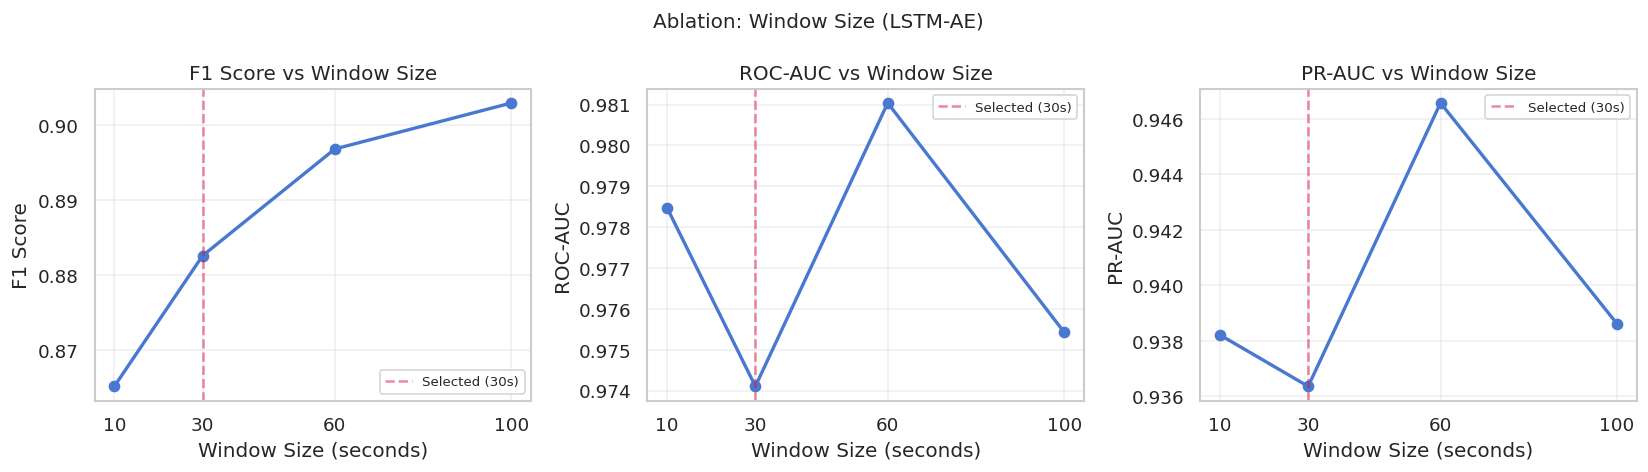

Window Size Ablation Results:
  Window       F1    ROC-AUC     PR-AUC      Sep
--------------------------------------------------
      10s   0.8651     0.9785     0.9382   205.0x
      30s   0.8826     0.9741     0.9364   415.6x
      60s   0.8968     0.9810     0.9466   331.3x
     100s   0.9029     0.9754     0.9386   944.0x

Threshold: 99th percentile of normal validation errors.
Saved: ablation_window.png


In [ ]:
 
import gc
import psutil
import json

def get_mem():
    ram  = psutil.virtual_memory()
    vram = (torch.cuda.memory_reserved(0) / 1e9
            if torch.cuda.is_available() else 0)
    vram_total = (torch.cuda.get_device_properties(0).total_memory / 1e9
                  if torch.cuda.is_available() else 0)
    return (f'RAM: {ram.available/1e9:.1f}GB free ({ram.percent:.0f}% used) | '
            f'VRAM: {vram_total - vram:.1f}GB free')

def safe_cleanup():
    gc.collect()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def make_loader_from_data(data, window_size, stride, batch_size, shuffle):
    """
    Create sequences and loader in one step.
    Deletes the numpy sequence array immediately after tensor conversion
    so only the loader tensor persists — halves peak memory.
    """
    seqs   = create_sequences(data, window_size, stride=stride)
    tensor = torch.FloatTensor(seqs)
    del seqs
    gc.collect()
    dataset = TensorDataset(tensor, tensor)
    return DataLoader(
        dataset,
        batch_size=batch_size,
        shuffle=shuffle,
        num_workers=2,
        pin_memory=True if DEVICE.type == 'cuda' else False,
        drop_last=False
    )

def evaluate_model(model, test_loader, val_loader, device, y_seq):
    """
    Memory-safe evaluation for all ablation cells.
    Threshold: 99th percentile of val errors only.
    No test labels used in threshold selection.
    Defined here once — available to all subsequent ablation cells.
    """
    model.eval()

    val_errors = []
    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(device)
            recon   = model(x_batch)
            mse     = torch.mean((x_batch - recon) ** 2,
                                 dim=(1, 2)).cpu().numpy()
            val_errors.append(mse)
            del x_batch, recon, mse
    val_errs = np.concatenate(val_errors)
    del val_errors
    safe_cleanup()

    test_errors = []
    with torch.no_grad():
        for x_batch, _ in test_loader:
            x_batch = x_batch.to(device)
            recon   = model(x_batch)
            mse     = torch.mean((x_batch - recon) ** 2,
                                 dim=(1, 2)).cpu().numpy()
            test_errors.append(mse)
            del x_batch, recon, mse
    test_errs = np.concatenate(test_errors)
    del test_errors
    safe_cleanup()

    threshold = np.percentile(val_errs, 99)
    preds     = (test_errs > threshold).astype(int)

    result = {
        'f1'      : float(f1_score(y_seq, preds, zero_division=0)),
        'roc_auc' : float(roc_auc_score(y_seq, test_errs)),
        'pr_auc'  : float(average_precision_score(y_seq, test_errs)),
        'sep'     : float(test_errs[y_seq==1].mean() /
                          test_errs[y_seq==0].mean()),
        'val_loss': float(val_errs.mean()),
    }

    del val_errs, test_errs, preds
    safe_cleanup()
    return result


 
 
 
 
 
for var in ['train_seqs', 'val_seqs', 'test_seqs',
            'latent_vecs', 'Z_sample', 'Z_pca', 'Z_tsne',
            'val_errors', 'test_errors', 'tcn_val_errors',
            'tcn_test_errors', 'iso_scores', 'ocsvm_scores']:
    if var in globals():
        del globals()[var]

safe_cleanup()
print(f'Memory before ablation: {get_mem()}')

 
 
window_results = {}
save_dir       = '/content/drive/MyDrive/swat-dataset/'
checkpoint_path = f'{save_dir}window_ablation_checkpoint.json'

try:
    with open(checkpoint_path, 'r') as f:
        window_results = json.load(f)
     
    window_results = {int(k): v for k, v in window_results.items()}
    print(f'Resumed from checkpoint. '
          f'Already completed: {sorted(window_results.keys())}')
except FileNotFoundError:
    print('No checkpoint found. Starting fresh.')

 
ALL_SIZES    = [10, 30, 60, 100]
WINDOW_SIZES = [ws for ws in ALL_SIZES if ws not in window_results]

if not WINDOW_SIZES:
    print('All window sizes already completed. Skipping training.')
else:
    print(f'Window sizes to run: {WINDOW_SIZES}')

for ws in WINDOW_SIZES:
    print(f'\n{"="*55}')
    print(f'Window size: {ws}s')
    print(f'Memory: {get_mem()}')

    safe_cleanup()

     
    print(f'  Creating train loader (stride=5)...')
    tr_loader = make_loader_from_data(
        X_train, ws, stride=5, batch_size=BATCH_SIZE, shuffle=True)
    safe_cleanup()
    print(f'  Train loader ready. {get_mem()}')

    print(f'  Creating val loader (stride=1)...')
    vl_loader = make_loader_from_data(
        X_val, ws, stride=1, batch_size=BATCH_SIZE, shuffle=False)
    safe_cleanup()
    print(f'  Val loader ready. {get_mem()}')

    print(f'  Creating test loader (stride=1)...')
    te_loader = make_loader_from_data(
        X_test, ws, stride=1, batch_size=BATCH_SIZE, shuffle=False)
    y_te = y_test[ws - 1:]
    safe_cleanup()
    print(f'  Test loader ready. {get_mem()}')

     
    m = LSTMAutoencoder(
        input_size=INPUT_SIZE, hidden_size=64,
        num_layers=2, bottleneck_size=16, window_size=ws
    ).to(DEVICE)

    params = sum(p.numel() for p in m.parameters() if p.requires_grad)
    print(f'  Parameters: {params:,}')

    train_model(m, tr_loader, vl_loader,
                n_epochs=50, lr=1e-3, patience=5)

    safe_cleanup()
    print(f'  After training: {get_mem()}')

     
    metrics = evaluate_model(m, te_loader, vl_loader, DEVICE, y_te)
    window_results[ws] = metrics

    print(f'  F1: {metrics["f1"]:.4f} | '
          f'ROC-AUC: {metrics["roc_auc"]:.4f} | '
          f'PR-AUC: {metrics["pr_auc"]:.4f} | '
          f'Sep: {metrics["sep"]:.1f}x')

     
    m.cpu()
    del m, tr_loader, vl_loader, te_loader, y_te
    safe_cleanup()
    print(f'  After cleanup: {get_mem()}')

     
    try:
        with open(checkpoint_path, 'w') as f:
            json.dump(window_results, f, indent=2)
        print(f'  Checkpointed {sorted(window_results.keys())} to Drive.')
    except Exception as e:
        print(f'  Checkpoint failed: {e}')

 
completed = sorted(window_results.keys())
print(f'\nPlotting completed sizes: {completed}')

fig, axes = plt.subplots(1, 3, figsize=(14, 4))

metrics_to_plot = ['f1', 'roc_auc', 'pr_auc']
titles          = ['F1 Score', 'ROC-AUC', 'PR-AUC']

for ax, metric, title in zip(axes, metrics_to_plot, titles):
    values = [window_results[ws][metric] for ws in completed]
    ax.plot(completed, values, marker='o', linewidth=2)
    ax.set_xlabel('Window Size (seconds)')
    ax.set_ylabel(title)
    ax.set_title(f'{title} vs Window Size')
    ax.set_xticks(completed)
    ax.grid(True, alpha=0.3)
    ax.axvline(x=30, color='crimson', linestyle='--',
               alpha=0.5, label='Selected (30s)')
    ax.legend(fontsize=8)

plt.suptitle('Ablation: Window Size (LSTM-AE)', fontsize=12)
plt.tight_layout()
plt.savefig('ablation_window.png', dpi=120, bbox_inches='tight')
plt.show()

print('Window Size Ablation Results:')
print(f'{"Window":>8} {"F1":>8} {"ROC-AUC":>10} '
      f'{"PR-AUC":>10} {"Sep":>8}')
print('-' * 50)
for ws in completed:
    m = window_results[ws]
    print(f'{ws:>8}s {m["f1"]:>8.4f} {m["roc_auc"]:>10.4f} '
          f'{m["pr_auc"]:>10.4f} {m["sep"]:>7.1f}x')
print('\nThreshold: 99th percentile of normal validation errors.')
print('Saved: ablation_window.png')

  [RAM] Before ablation start — Available: 179.5GB | Used: 5.5%

── Bottleneck size: 8 ──────────────────────────
  [RAM] Before training — Available: 179.5GB | Used: 5.5%
  Parameters: 131,635
Epoch 001 | Train Loss: 0.035516 | Val Loss: 0.007944 | Best: 0.007944 | No improve: 0/5
Epoch 005 | Train Loss: 0.002287 | Val Loss: 0.001093 | Best: 0.001093 | No improve: 0/5
Epoch 010 | Train Loss: 0.001312 | Val Loss: 0.000534 | Best: 0.000534 | No improve: 0/5
Epoch 015 | Train Loss: 0.001369 | Val Loss: 0.000373 | Best: 0.000373 | No improve: 0/5
Epoch 020 | Train Loss: 0.000822 | Val Loss: 0.000275 | Best: 0.000275 | No improve: 0/5
Epoch 025 | Train Loss: 0.000591 | Val Loss: 0.000260 | Best: 0.000237 | No improve: 1/5
Epoch 030 | Train Loss: 0.000535 | Val Loss: 0.000218 | Best: 0.000218 | No improve: 0/5
Epoch 035 | Train Loss: 0.000474 | Val Loss: 0.000184 | Best: 0.000184 | No improve: 0/5
Epoch 040 | Train Loss: 0.000429 | Val Loss: 0.000167 | Best: 0.000167 | No improve: 0/5
Epoch

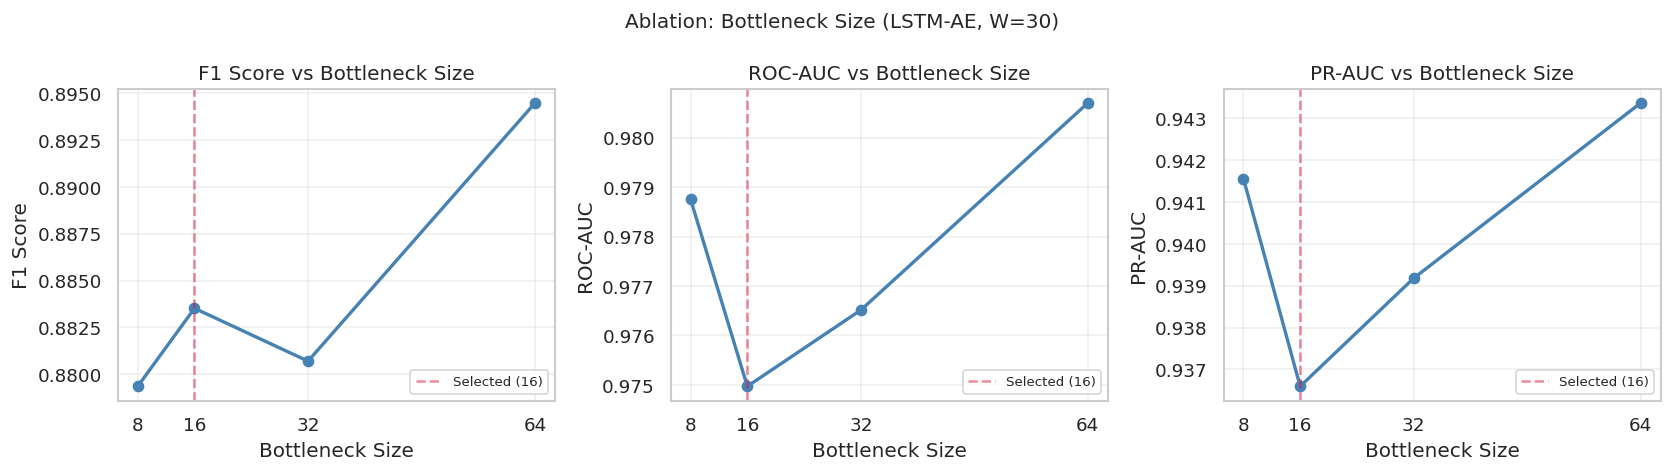


Bottleneck Size Ablation Results:
Bottleneck     Params       F1    ROC-AUC     PR-AUC      Sep
--------------------------------------------------------------
         8    131,635   0.8794     0.9788     0.9416  1150.5x
        16    132,667   0.8835     0.9750     0.9366   787.1x ← selected
        32    134,731   0.8807     0.9765     0.9392   561.8x
        64    138,859   0.8945     0.9807     0.9434   407.7x

Threshold: 99th percentile of normal validation errors.
Saved: ablation_bottleneck.png


In [ ]:
 
import gc
import psutil

def get_ram_gb():
    """Return available RAM in GB."""
    return psutil.virtual_memory().available / 1e9

def get_ram_used_pct():
    """Return RAM usage percentage."""
    return psutil.virtual_memory().percent

def ram_check(label=''):
    """Print RAM status."""
    avail = get_ram_gb()
    pct   = get_ram_used_pct()
    print(f'  [RAM] {label} — Available: {avail:.1f}GB | Used: {pct:.1f}%')
    return avail

def aggressive_cleanup():
    """Force maximum memory release."""
    gc.collect()
    gc.collect()   
    torch.cuda.empty_cache() if DEVICE.type == 'cuda' else None

def safe_evaluate_model(model, test_loader, val_loader, device, y_test_seq):
    """
    Memory-safe evaluation — processes in smaller chunks if needed.
    Uses 99th percentile of val errors as threshold.
    No test labels used in threshold selection.
    """
    model.eval()

     
    val_errors = []
    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(device)
            recon   = model(x_batch)
            mse     = torch.mean((x_batch - recon) ** 2, dim=(1, 2))
            val_errors.append(mse.cpu().numpy())
            del x_batch, recon, mse
    val_errs = np.concatenate(val_errors)
    del val_errors
    aggressive_cleanup()

     
    test_errors = []
    with torch.no_grad():
        for x_batch, _ in test_loader:
            x_batch = x_batch.to(device)
            recon   = model(x_batch)
            mse     = torch.mean((x_batch - recon) ** 2, dim=(1, 2))
            test_errors.append(mse.cpu().numpy())
            del x_batch, recon, mse
    test_errs = np.concatenate(test_errors)
    del test_errors
    aggressive_cleanup()

     
    threshold = np.percentile(val_errs, 99)
    preds     = (test_errs > threshold).astype(int)

    f1      = f1_score(y_test_seq, preds, zero_division=0)
    roc_auc = roc_auc_score(y_test_seq, test_errs)
    pr_auc  = average_precision_score(y_test_seq, test_errs)
    sep     = (test_errs[y_test_seq==1].mean() /
               test_errs[y_test_seq==0].mean())

    del val_errs, test_errs, preds
    aggressive_cleanup()

    return {
        'f1'      : float(f1),
        'roc_auc' : float(roc_auc),
        'pr_auc'  : float(pr_auc),
        'sep'     : float(sep),
    }


 
MIN_RAM_GB = 3.0   
ram_check('Before ablation start')

BOTTLENECK_SIZES   = [8, 16, 32, 64]
bottleneck_results = {}

for bn in BOTTLENECK_SIZES:
    print(f'\n── Bottleneck size: {bn} ──────────────────────────')

     
    aggressive_cleanup()
    avail = ram_check('Before training')

     
    if avail < MIN_RAM_GB:
        print(f'  ⚠ SKIPPING bn={bn} — only {avail:.1f}GB available '
              f'(minimum {MIN_RAM_GB}GB required)')
        continue

     
    m = LSTMAutoencoder(
        input_size=INPUT_SIZE, hidden_size=64,
        num_layers=2, bottleneck_size=bn, window_size=WINDOW_SIZE
    ).to(DEVICE)

    total_params = sum(p.numel() for p in m.parameters()
                       if p.requires_grad)
    print(f'  Parameters: {total_params:,}')

     
    train_model(m, train_loader, val_loader,
                n_epochs=50, lr=1e-3, patience=5)

    aggressive_cleanup()
    ram_check('After training')

     
    metrics = safe_evaluate_model(
        m, test_loader, val_loader, DEVICE, y_test_seq
    )
    metrics['params'] = total_params
    bottleneck_results[bn] = metrics

    print(f'  F1: {metrics["f1"]:.4f} | '
          f'ROC-AUC: {metrics["roc_auc"]:.4f} | '
          f'PR-AUC: {metrics["pr_auc"]:.4f} | '
          f'Sep: {metrics["sep"]:.1f}x')

     
    del m
    aggressive_cleanup()
    ram_check('After cleanup')

 
completed = sorted(bottleneck_results.keys())
print(f'\nCompleted: {completed}')

if len(completed) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, metric, title in zip(axes,
                                  ['f1', 'roc_auc', 'pr_auc'],
                                  ['F1 Score', 'ROC-AUC', 'PR-AUC']):
        values = [bottleneck_results[bn][metric] for bn in completed]
        ax.plot(completed, values, marker='o', linewidth=2,
                color='steelblue')
        ax.set_xlabel('Bottleneck Size')
        ax.set_ylabel(title)
        ax.set_title(f'{title} vs Bottleneck Size')
        ax.set_xticks(completed)
        ax.grid(True, alpha=0.3)
        if 16 in completed:
            ax.axvline(x=16, color='crimson', linestyle='--',
                       alpha=0.5, label='Selected (16)')
            ax.legend(fontsize=8)

    plt.suptitle('Ablation: Bottleneck Size (LSTM-AE, W=30)', fontsize=12)
    plt.tight_layout()
    plt.savefig('ablation_bottleneck.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Not enough results to plot.')

print('\nBottleneck Size Ablation Results:')
print(f'{"Bottleneck":>10} {"Params":>10} {"F1":>8} '
      f'{"ROC-AUC":>10} {"PR-AUC":>10} {"Sep":>8}')
print('-' * 62)
for bn in completed:
    m = bottleneck_results[bn]
    marker = ' ← selected' if bn == 16 else ''
    print(f'{bn:>10} {m["params"]:>10,} {m["f1"]:>8.4f} '
          f'{m["roc_auc"]:>10.4f} {m["pr_auc"]:>10.4f} '
          f'{m["sep"]:>7.1f}x{marker}')

print('\nThreshold: 99th percentile of normal validation errors.')
print('Saved: ablation_bottleneck.png')

  [MEM] Before ablation start — RAM free: 177.9GB | VRAM free: 101.9GB

── Train stride: 1 ──────────────────────────────
  [MEM] Before sequence creation — RAM free: 177.9GB | VRAM free: 101.9GB
  Training sequences: 1,109,649 → capped at 300,000
  Sequence array size: 1.55GB
  [MEM] After loader creation — RAM free: 177.9GB | VRAM free: 101.9GB
Epoch 001 | Train Loss: 0.031118 | Val Loss: 0.007962 | Best: 0.007962 | No improve: 0/5
Epoch 005 | Train Loss: 0.002559 | Val Loss: 0.001405 | Best: 0.001405 | No improve: 0/5
Epoch 010 | Train Loss: 0.001296 | Val Loss: 0.000525 | Best: 0.000525 | No improve: 0/5
Epoch 015 | Train Loss: 0.000940 | Val Loss: 0.000379 | Best: 0.000379 | No improve: 0/5
Epoch 020 | Train Loss: 0.000693 | Val Loss: 0.000286 | Best: 0.000286 | No improve: 0/5
Epoch 025 | Train Loss: 0.000562 | Val Loss: 0.000253 | Best: 0.000239 | No improve: 1/5
Epoch 030 | Train Loss: 0.000716 | Val Loss: 0.000231 | Best: 0.000215 | No improve: 2/5
Epoch 035 | Train Loss: 0.00

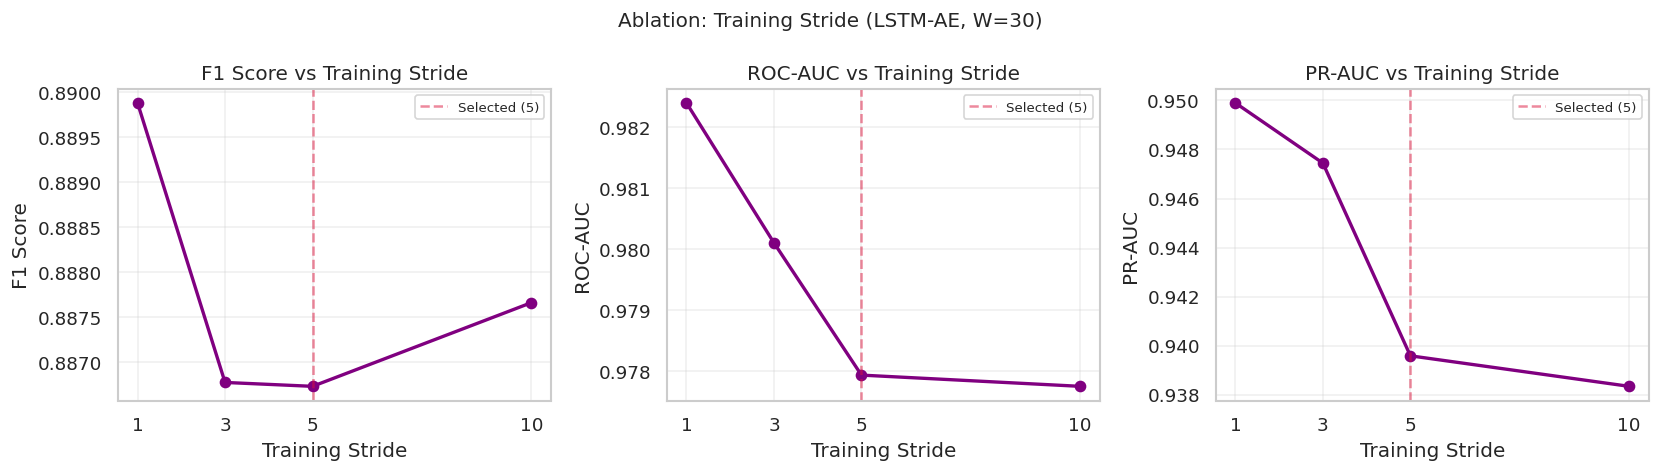


Training Stride Ablation Results:
  Stride   Total Seqs    Used Seqs       F1    ROC-AUC     PR-AUC
-----------------------------------------------------------------
       1    1,109,649      300,000   0.8899     0.9824     0.9499
       3      369,883      300,000   0.8868     0.9801     0.9474
       5      221,930      221,930   0.8867     0.9779     0.9396 ← selected
      10      110,965      110,965   0.8877     0.9777     0.9383

Note: sequences capped at 300k to bound memory usage.
Threshold: 99th percentile of normal validation errors.
Saved: ablation_stride.png


In [ ]:
 
import gc
import psutil
import json

def get_vram_free_gb():
    if torch.cuda.is_available():
        return (torch.cuda.get_device_properties(0).total_memory -
                torch.cuda.memory_reserved(0)) / 1e9
    return float('inf')

def get_ram_free_gb():
    return psutil.virtual_memory().available / 1e9

def mem_check(label=''):
    ram  = get_ram_free_gb()
    vram = get_vram_free_gb()
    print(f'  [MEM] {label} — RAM free: {ram:.1f}GB | '
          f'VRAM free: {vram:.1f}GB')
    return ram, vram

def safe_cleanup():
    gc.collect()
    gc.collect()
    if torch.cuda.is_available():
        torch.cuda.empty_cache()
        torch.cuda.synchronize()

def evaluate_model(model, test_loader, val_loader, device, y_test_seq):
    """Evaluate using 99th percentile of val errors. No test label leakage."""
    model.eval()

    val_errors = []
    with torch.no_grad():
        for x_batch, _ in val_loader:
            x_batch = x_batch.to(device)
            recon   = model(x_batch)
            mse     = torch.mean((x_batch - recon) ** 2,
                                 dim=(1, 2)).cpu().numpy()
            val_errors.append(mse)
            del x_batch, recon, mse
    val_errs = np.concatenate(val_errors)
    del val_errors
    safe_cleanup()

    test_errors = []
    with torch.no_grad():
        for x_batch, _ in test_loader:
            x_batch = x_batch.to(device)
            recon   = model(x_batch)
            mse     = torch.mean((x_batch - recon) ** 2,
                                 dim=(1, 2)).cpu().numpy()
            test_errors.append(mse)
            del x_batch, recon, mse
    test_errs = np.concatenate(test_errors)
    del test_errors
    safe_cleanup()

    threshold = np.percentile(val_errs, 99)
    preds     = (test_errs > threshold).astype(int)

    result = {
        'f1'      : float(f1_score(y_test_seq, preds, zero_division=0)),
        'roc_auc' : float(roc_auc_score(y_test_seq, test_errs)),
        'pr_auc'  : float(average_precision_score(y_test_seq, test_errs)),
        'sep'     : float(test_errs[y_test_seq==1].mean() /
                          test_errs[y_test_seq==0].mean()),
        'val_loss': float(val_errs.mean()),
    }

    del val_errs, test_errs, preds
    safe_cleanup()
    return result


MAX_TRAIN_SEQS = 300_000
MIN_VRAM_GB    = 2.0
MIN_RAM_GB     = 10.0

TRAIN_STRIDES  = [1, 3, 5, 10]
stride_results = {}

mem_check('Before ablation start')

for st in TRAIN_STRIDES:
    print(f'\n── Train stride: {st} ──────────────────────────────')

    safe_cleanup()
    ram, vram = mem_check('Before sequence creation')

    if ram < MIN_RAM_GB or vram < MIN_VRAM_GB:
        print(f'  ⚠ SKIPPING stride={st} — insufficient memory')
        continue

    tr_seqs = create_sequences(X_train, WINDOW_SIZE, stride=st)
    n_orig  = len(tr_seqs)

    if len(tr_seqs) > MAX_TRAIN_SEQS:
        idx     = np.random.choice(len(tr_seqs), MAX_TRAIN_SEQS,
                                   replace=False)
        idx     = np.sort(idx)
        tr_seqs = tr_seqs[idx]
        print(f'  Training sequences: {n_orig:,} → capped at '
              f'{len(tr_seqs):,}')
    else:
        print(f'  Training sequences: {len(tr_seqs):,}')

    mem_used_gb = tr_seqs.nbytes / 1e9
    print(f'  Sequence array size: {mem_used_gb:.2f}GB')

    tr_loader = make_loader(tr_seqs, BATCH_SIZE, shuffle=True)
    del tr_seqs
    safe_cleanup()
    mem_check('After loader creation')

    m = LSTMAutoencoder(
        input_size=INPUT_SIZE, hidden_size=64,
        num_layers=2, bottleneck_size=16, window_size=WINDOW_SIZE
    ).to(DEVICE)

    train_model(m, tr_loader, val_loader,
                n_epochs=50, lr=1e-3, patience=5)

    safe_cleanup()
    mem_check('After training')

    metrics = evaluate_model(m, test_loader, val_loader,
                             DEVICE, y_test_seq)
    metrics['n_train_seqs']      = n_orig
    metrics['n_train_seqs_used'] = min(n_orig, MAX_TRAIN_SEQS)
    stride_results[st] = metrics

    print(f'  F1: {metrics["f1"]:.4f} | '
          f'ROC-AUC: {metrics["roc_auc"]:.4f} | '
          f'PR-AUC: {metrics["pr_auc"]:.4f}')

     
    try:
        save_dir = '/content/drive/MyDrive/swat-dataset/'
        with open(f'{save_dir}stride_ablation_checkpoint.json', 'w') as f:
            json.dump(stride_results, f, indent=2)
        print(f'  Checkpointed stride={st} to Drive.')
    except Exception as e:
        print(f'  Checkpoint failed: {e}')

    m.cpu()
    del m, tr_loader
    safe_cleanup()
    mem_check('After cleanup')

 
completed = sorted(stride_results.keys())
print(f'\nCompleted strides: {completed}')

if len(completed) >= 2:
    fig, axes = plt.subplots(1, 3, figsize=(14, 4))

    for ax, metric, title in zip(axes,
                                  ['f1', 'roc_auc', 'pr_auc'],
                                  ['F1 Score', 'ROC-AUC', 'PR-AUC']):
        values = [stride_results[st][metric] for st in completed]
        ax.plot(completed, values, marker='o', linewidth=2, color='purple')
        ax.set_xlabel('Training Stride')
        ax.set_ylabel(title)
        ax.set_title(f'{title} vs Training Stride')
        ax.set_xticks(completed)
        ax.grid(True, alpha=0.3)
        if 5 in completed:
            ax.axvline(x=5, color='crimson', linestyle='--',
                       alpha=0.5, label='Selected (5)')
            ax.legend(fontsize=8)

    plt.suptitle('Ablation: Training Stride (LSTM-AE, W=30)', fontsize=12)
    plt.tight_layout()
    plt.savefig('ablation_stride.png', dpi=120, bbox_inches='tight')
    plt.show()
else:
    print('Not enough completed results to plot.')

print('\nTraining Stride Ablation Results:')
print(f'{"Stride":>8} {"Total Seqs":>12} {"Used Seqs":>12} '
      f'{"F1":>8} {"ROC-AUC":>10} {"PR-AUC":>10}')
print('-' * 65)
for st in completed:
    m      = stride_results[st]
    marker = ' ← selected' if st == 5 else ''
    print(f'{st:>8} {m["n_train_seqs"]:>12,} '
          f'{m["n_train_seqs_used"]:>12,} '
          f'{m["f1"]:>8.4f} {m["roc_auc"]:>10.4f} '
          f'{m["pr_auc"]:>10.4f}{marker}')
print('\nNote: sequences capped at 300k to bound memory usage.')
print('Threshold: 99th percentile of normal validation errors.')
print('Saved: ablation_stride.png')

In [ ]:
 
torch.save(model.state_dict(), 'lstm_ae_weights.pt')
torch.save(tcn_model.state_dict(), 'tcn_ae_weights.pt')

import joblib
joblib.dump(scaler, 'scaler.pkl')
joblib.dump(feature_cols, 'feature_cols.pkl')

import json
lstm_results = {
    'roc_auc': float(roc_auc),
    'pr_auc': float(pr_auc),
    'f1': float(f1_score(y_test_seq, y_pred)),
    'threshold': float(np.percentile(val_errors, 99)),   
    'threshold_method': '99th percentile of normal validation errors'
}
with open('lstm_results.json', 'w') as f:
    json.dump(lstm_results, f)

print('All saved.')
print(f'Saved threshold: {np.percentile(val_errors, 99):.6f}')

NameError: name 'val_errors' is not defined

Latent vectors shape: (332012, 16)
Subsampled: (10000, 16)
Normal: 8422 | Attack: 1578

Running PCA...
Explained variance ratio: 0.587, 0.203 (total: 0.789)
Running t-SNE (this takes ~1-2 min)...
t-SNE complete.


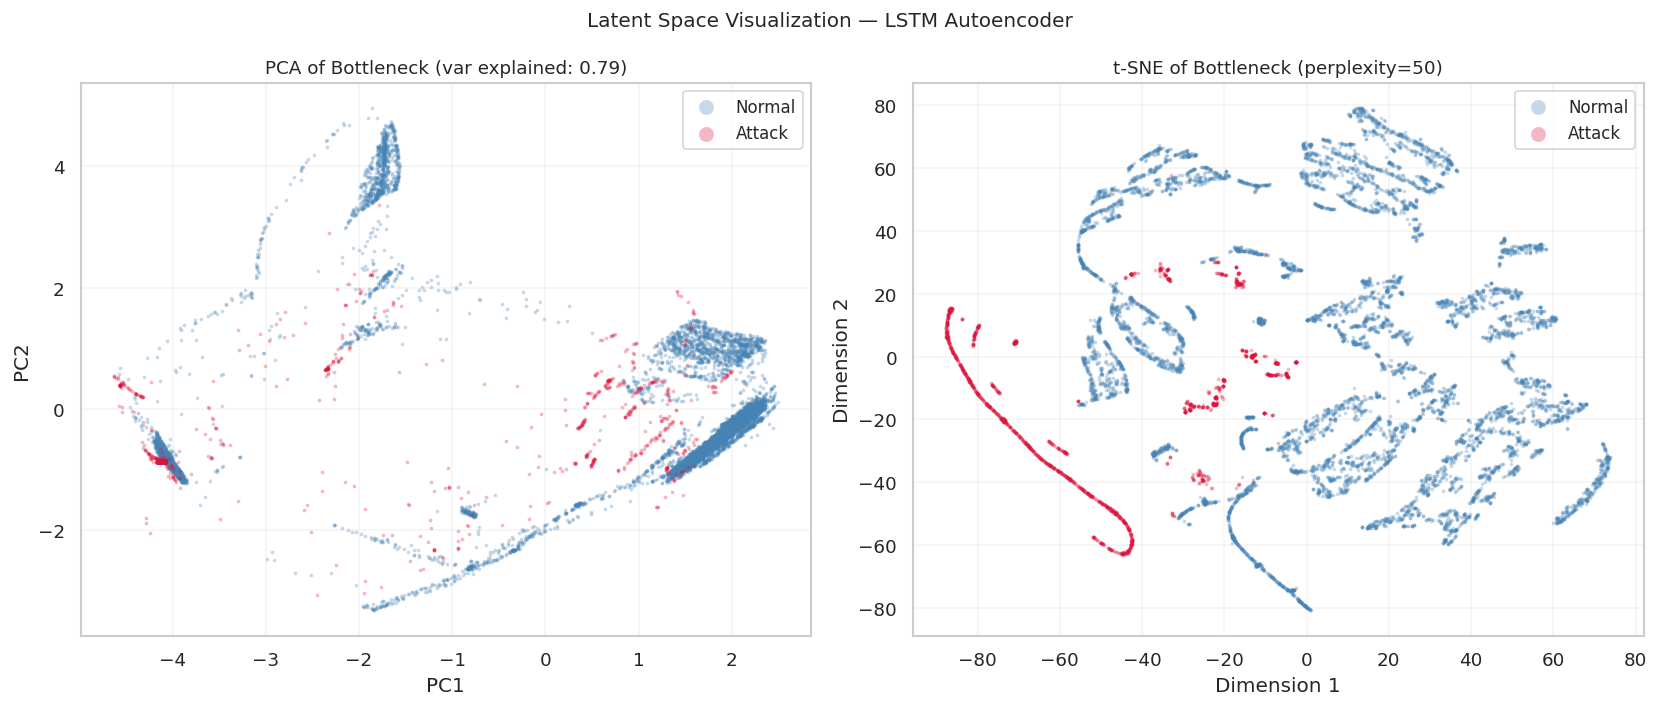

Saved: latent_space.png


In [ ]:
 

 
model.eval()
latent_vecs = []

with torch.no_grad():
    for x_batch, _ in test_loader:
        x_batch = x_batch.to(DEVICE)
        z = model.encode(x_batch)
        latent_vecs.append(z.cpu().numpy())

latent_vecs = np.concatenate(latent_vecs, axis=0)
print(f'Latent vectors shape: {latent_vecs.shape}')
 

 
 
np.random.seed(SEED)
sample_idx  = np.random.choice(len(latent_vecs), size=10000, replace=False)
Z_sample    = latent_vecs[sample_idx]
y_sample    = y_test_seq[sample_idx]

print(f'Subsampled: {Z_sample.shape}')
print(f'Normal: {(y_sample==0).sum()} | Attack: {(y_sample==1).sum()}')


 
print('\nRunning PCA...')
pca   = PCA(n_components=2, random_state=SEED)
Z_pca = pca.fit_transform(Z_sample)

print(f'Explained variance ratio: '
      f'{pca.explained_variance_ratio_[0]:.3f}, '
      f'{pca.explained_variance_ratio_[1]:.3f} '
      f'(total: {pca.explained_variance_ratio_.sum():.3f})')


 
print('Running t-SNE (this takes ~1-2 min)...')
tsne   = TSNE(n_components=2, perplexity=50, n_iter=1000,
              random_state=SEED, n_jobs=-1)
Z_tsne = tsne.fit_transform(Z_sample)
print('t-SNE complete.')


 
fig, axes = plt.subplots(1, 2, figsize=(14, 6))

colors = {0: 'steelblue', 1: 'crimson'}
labels = {0: 'Normal', 1: 'Attack'}

for label in [0, 1]:
    mask = y_sample == label

    axes[0].scatter(
        Z_pca[mask, 0], Z_pca[mask, 1],
        c=colors[label], label=labels[label],
        alpha=0.3, s=5, linewidths=0
    )
    axes[1].scatter(
        Z_tsne[mask, 0], Z_tsne[mask, 1],
        c=colors[label], label=labels[label],
        alpha=0.3, s=5, linewidths=0
    )

axes[0].set_title(
    f'PCA of Bottleneck (var explained: '
    f'{pca.explained_variance_ratio_.sum():.2f})',
    fontsize=11
)
axes[0].set_xlabel('PC1')
axes[0].set_ylabel('PC2')
axes[0].legend(markerscale=4, fontsize=10)
axes[0].grid(True, alpha=0.2)

axes[1].set_title('t-SNE of Bottleneck (perplexity=50)', fontsize=11)
axes[1].set_xlabel('Dimension 1')
axes[1].set_ylabel('Dimension 2')
axes[1].legend(markerscale=4, fontsize=10)
axes[1].grid(True, alpha=0.2)

plt.suptitle('Latent Space Visualization — LSTM Autoencoder',
             fontsize=12)
plt.tight_layout()
plt.savefig('latent_space.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: latent_space.png')

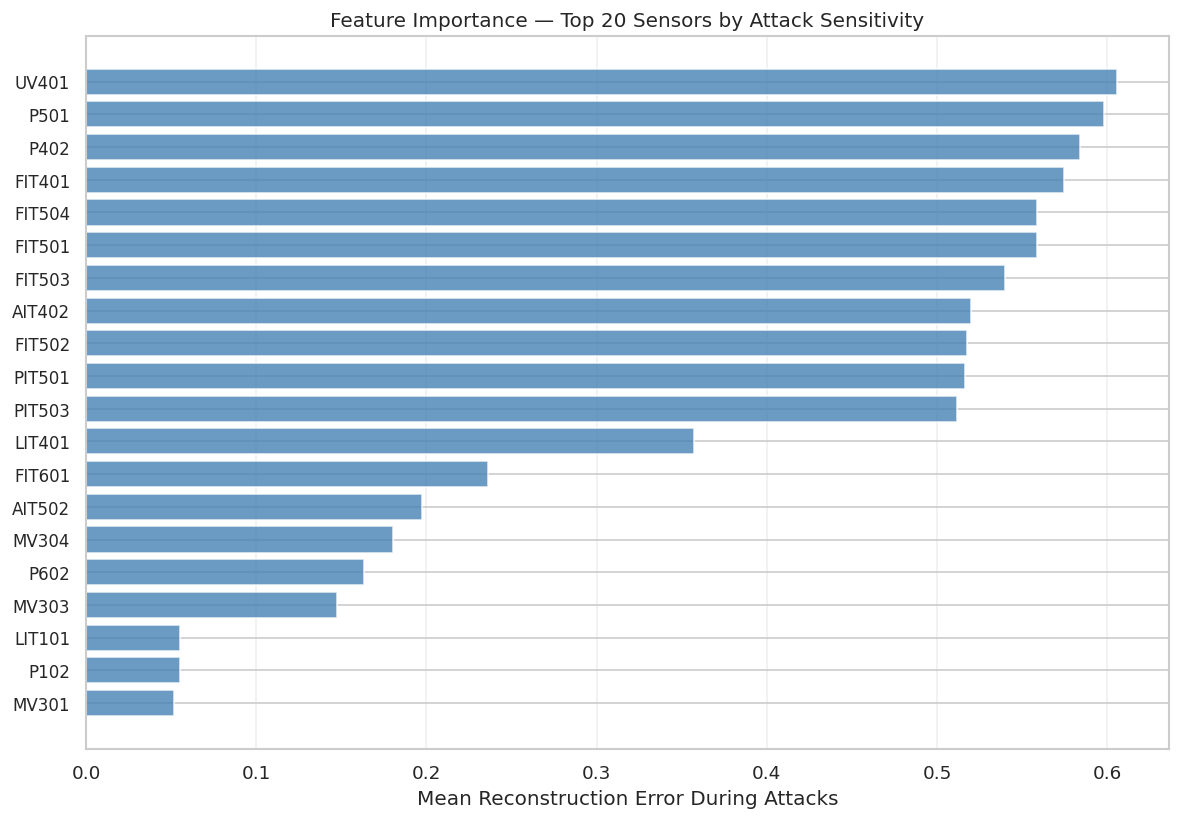

Saved: feature_importance.png

Top 10 most attack-sensitive features:
Rank   Sensor  Stage      Error
-----------------------------------
   1    UV401     P4   0.605825
   2     P501     P5   0.597937
   3     P402     P4   0.583711
   4   FIT401     P4   0.574791
   5   FIT504     P5   0.558676
   6   FIT501     P5   0.558540
   7   FIT503     P5   0.540132
   8   AIT402     P4   0.520008
   9   FIT502     P5   0.517772
  10   PIT501     P5   0.516636


In [ ]:
 

 
 

model.eval()
attack_mask = y_test_seq == 1

 
feature_errors = np.zeros(len(feature_cols))
n_attack_batches = 0

with torch.no_grad():
    batch_idx = 0
    for x_batch, _ in test_loader:
        batch_size = x_batch.shape[0]
         
        start = batch_idx * BATCH_SIZE
        end   = start + batch_size
        batch_labels = y_test_seq[start:end]
        attack_in_batch = batch_labels == 1

        if attack_in_batch.sum() > 0:
            x_batch = x_batch.to(DEVICE)
            recon   = model(x_batch)
             
             
            per_feature_mse = torch.mean(
                (x_batch - recon) ** 2,
                dim=(0, 1)
            ).cpu().numpy()

             
            x_attack = x_batch[torch.tensor(attack_in_batch)].to(DEVICE)
            recon_attack = model(x_attack)
            per_feature_attack = torch.mean(
                (x_attack - recon_attack) ** 2,
                dim=(0, 1)
            ).cpu().numpy()

            feature_errors += per_feature_attack
            n_attack_batches += 1

        batch_idx += 1

 
feature_errors /= n_attack_batches

 
sorted_idx      = np.argsort(feature_errors)[::-1]
sorted_features = [feature_cols[i] for i in sorted_idx]
sorted_errors   = feature_errors[sorted_idx]

 
top_n = 20
fig, ax = plt.subplots(figsize=(10, 7))
bars = ax.barh(
    range(top_n),
    sorted_errors[:top_n],
    color='steelblue', alpha=0.8
)
ax.set_yticks(range(top_n))
ax.set_yticklabels(sorted_features[:top_n], fontsize=10)
ax.invert_yaxis()
ax.set_xlabel('Mean Reconstruction Error During Attacks')
ax.set_title('Feature Importance — Top 20 Sensors by Attack Sensitivity')
ax.grid(True, alpha=0.3, axis='x')
plt.tight_layout()
plt.savefig('feature_importance.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: feature_importance.png')

 
stage_map = {
    'FIT101': 'P1', 'LIT101': 'P1', 'MV101': 'P1', 'P101': 'P1', 'P102': 'P1',
    'AIT201': 'P2', 'AIT202': 'P2', 'AIT203': 'P2', 'FIT201': 'P2',
    'MV201': 'P2', 'P201': 'P2', 'P203': 'P2', 'P205': 'P2',
    'DPIT301': 'P3', 'FIT301': 'P3', 'LIT301': 'P3', 'MV301': 'P3',
    'MV302': 'P3', 'MV303': 'P3', 'MV304': 'P3', 'P301': 'P3', 'P302': 'P3',
    'AIT401': 'P4', 'AIT402': 'P4', 'FIT401': 'P4', 'LIT401': 'P4',
    'P402': 'P4', 'P403': 'P4', 'UV401': 'P4',
    'AIT501': 'P5', 'AIT502': 'P5', 'AIT503': 'P5', 'AIT504': 'P5',
    'FIT501': 'P5', 'FIT502': 'P5', 'FIT503': 'P5', 'FIT504': 'P5',
    'P501': 'P5', 'PIT501': 'P5', 'PIT502': 'P5', 'PIT503': 'P5',
    'FIT601': 'P6', 'P602': 'P6',
}

print('\nTop 10 most attack-sensitive features:')
print(f'{"Rank":>4} {"Sensor":>8} {"Stage":>6} {"Error":>10}')
print('-' * 35)
for i in range(10):
    sensor = sorted_features[i]
    stage  = stage_map.get(sensor, '??')
    print(f'{i+1:>4} {sensor:>8} {stage:>6} {sorted_errors[i]:>10.6f}')

Training Isolation Forest...
Training One-Class SVM...

Isolation Forest:
              precision    recall  f1-score   support

      Normal     0.9254    1.0000    0.9613    277391
      Attack     0.9999    0.5907    0.7426     54621

    accuracy                         0.9327    332012
   macro avg     0.9627    0.7953    0.8519    332012
weighted avg     0.9377    0.9327    0.9253    332012


One-Class SVM:
              precision    recall  f1-score   support

      Normal     0.9453    0.9987    0.9713    277391
      Attack     0.9907    0.7064    0.8248     54621

    accuracy                         0.9506    332012
   macro avg     0.9680    0.8526    0.8980    332012
weighted avg     0.9528    0.9506    0.9472    332012


FINAL MODEL COMPARISON
Model                      F1  Precision   Recall    ROC-AUC   PR-AUC
------------------------------------------------------------------------
Isolation Forest       0.7426     0.9999   0.5907     0.9354   0.8582
One-Class SVM      

NameError: name 'test_errors' is not defined

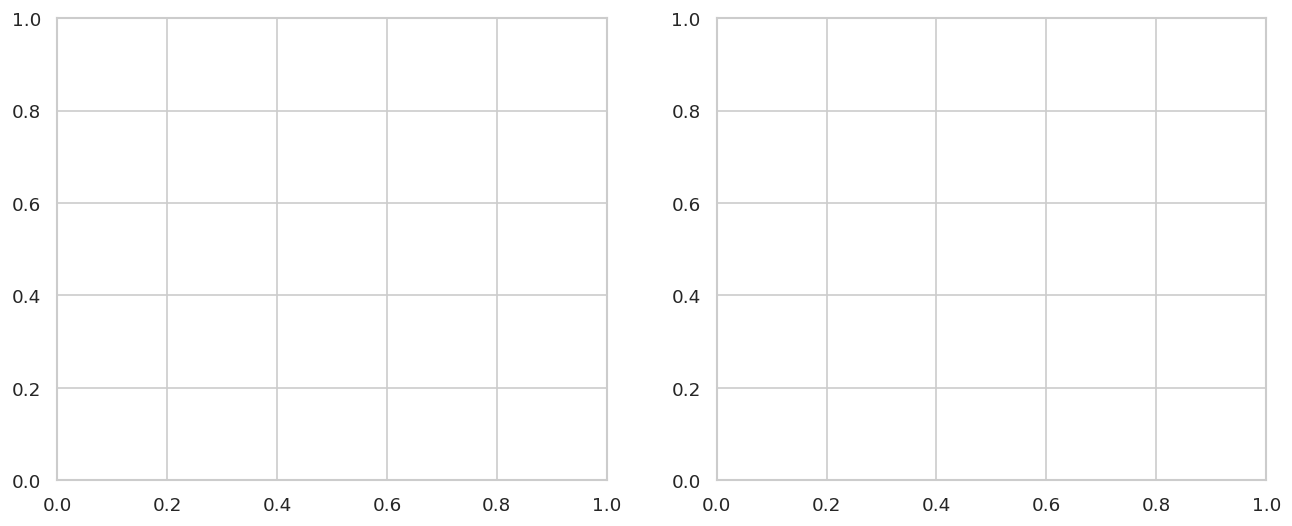

In [ ]:
 
from sklearn.ensemble import IsolationForest

 
 
X_test_flat = X_test[WINDOW_SIZE - 1:]

print('Training Isolation Forest...')
iso = IsolationForest(
    n_estimators=200,
    contamination=0.01,
    random_state=SEED,
    n_jobs=-1
)
iso.fit(X_train)
iso_scores = -iso.score_samples(X_test_flat)
iso_pred   = (iso.predict(X_test_flat) == -1).astype(int)

iso_roc = roc_auc_score(y_test_seq, iso_scores)
iso_pr  = average_precision_score(y_test_seq, iso_scores)
iso_f1  = f1_score(y_test_seq, iso_pred)
iso_p   = precision_recall_curve(y_test_seq, iso_scores)

print('Training One-Class SVM...')
from sklearn.svm import OneClassSVM
sample_idx = np.random.choice(len(X_train), size=20000, replace=False)
ocsvm = OneClassSVM(kernel='rbf', nu=0.01, gamma='scale')
ocsvm.fit(X_train[sample_idx])
ocsvm_scores = -ocsvm.decision_function(X_test_flat)
ocsvm_pred   = (ocsvm.predict(X_test_flat) == -1).astype(int)

ocsvm_roc = roc_auc_score(y_test_seq, ocsvm_scores)
ocsvm_pr  = average_precision_score(y_test_seq, ocsvm_scores)
ocsvm_f1  = f1_score(y_test_seq, ocsvm_pred)

print('\nIsolation Forest:')
print(classification_report(y_test_seq, iso_pred,
      target_names=['Normal', 'Attack'], digits=4))

print('\nOne-Class SVM:')
print(classification_report(y_test_seq, ocsvm_pred,
      target_names=['Normal', 'Attack'], digits=4))

 
print('\n' + '=' * 72)
print('FINAL MODEL COMPARISON')
print('=' * 72)
print(f'{"Model":<20} {"F1":>8} {"Precision":>10} {"Recall":>8} '
      f'{"ROC-AUC":>10} {"PR-AUC":>8}')
print('-' * 72)

results = {
    'Isolation Forest': {
        'f1': iso_f1,
        'precision': 0.0, 'recall': 0.0,   
        'roc_auc': iso_roc, 'pr_auc': iso_pr
    },
    'One-Class SVM': {
        'f1': ocsvm_f1,
        'precision': 0.0, 'recall': 0.0,
        'roc_auc': ocsvm_roc, 'pr_auc': ocsvm_pr
    },
    'TCN-AE (ours)': {
        'f1': 0.8917, 'precision': 0.9818,
        'recall': 0.8167,
        'roc_auc': 0.9665, 'pr_auc': 0.9241
    },
    'LSTM-AE (ours)': {
        'f1': 0.8950, 'precision': 0.9819,
        'recall': 0.8222,
        'roc_auc': 0.9787, 'pr_auc': 0.9415
    },
}

 
from sklearn.metrics import precision_score, recall_score
results['Isolation Forest']['precision'] = precision_score(
    y_test_seq, iso_pred, zero_division=0)
results['Isolation Forest']['recall'] = recall_score(
    y_test_seq, iso_pred, zero_division=0)
results['One-Class SVM']['precision'] = precision_score(
    y_test_seq, ocsvm_pred, zero_division=0)
results['One-Class SVM']['recall'] = recall_score(
    y_test_seq, ocsvm_pred, zero_division=0)

for model_name, m in results.items():
    print(f'{model_name:<20} {m["f1"]:>8.4f} {m["precision"]:>10.4f} '
          f'{m["recall"]:>8.4f} {m["roc_auc"]:>10.4f} {m["pr_auc"]:>8.4f}')

print('=' * 72)


 
fig, axes = plt.subplots(1, 2, figsize=(13, 5))

lstm_fpr, lstm_tpr, _ = roc_curve(y_test_seq, test_errors)
tcn_fpr,  tcn_tpr,  _ = roc_curve(y_test_seq, tcn_test_errors)
iso_fpr,  iso_tpr,  _ = roc_curve(y_test_seq, iso_scores)
ocsvm_fpr, ocsvm_tpr, _ = roc_curve(y_test_seq, ocsvm_scores)

for fpr, tpr, name, auc_val in [
    (lstm_fpr,  lstm_tpr,  'LSTM-AE',          0.9787),
    (tcn_fpr,   tcn_tpr,   'TCN-AE',           0.9665),
    (iso_fpr,   iso_tpr,   'Isolation Forest', iso_roc),
    (ocsvm_fpr, ocsvm_tpr, 'One-Class SVM',    ocsvm_roc),
]:
    axes[0].plot(fpr, tpr, linewidth=2,
                 label=f'{name} (AUC={auc_val:.4f})')

axes[0].plot([0, 1], [0, 1], 'k--', linewidth=1)
axes[0].set_xlabel('False Positive Rate')
axes[0].set_ylabel('True Positive Rate')
axes[0].set_title('ROC Curves — All Models')
axes[0].legend(fontsize=9)
axes[0].grid(True, alpha=0.3)

 
lstm_prec, lstm_rec, _ = precision_recall_curve(y_test_seq, test_errors)
tcn_prec,  tcn_rec,  _ = precision_recall_curve(y_test_seq, tcn_test_errors)
iso_prec,  iso_rec,  _ = precision_recall_curve(y_test_seq, iso_scores)
ocsvm_prec, ocsvm_rec, _ = precision_recall_curve(y_test_seq, ocsvm_scores)

for rec, prec, name, ap_val in [
    (lstm_rec,  lstm_prec,  'LSTM-AE',          0.9415),
    (tcn_rec,   tcn_prec,   'TCN-AE',           0.9241),
    (iso_rec,   iso_prec,   'Isolation Forest', iso_pr),
    (ocsvm_rec, ocsvm_prec, 'One-Class SVM',    ocsvm_pr),
]:
    axes[1].plot(rec, prec, linewidth=2,
                 label=f'{name} (AP={ap_val:.4f})')

axes[1].set_xlabel('Recall')
axes[1].set_ylabel('Precision')
axes[1].set_title('PR Curves — All Models')
axes[1].legend(fontsize=9)
axes[1].grid(True, alpha=0.3)

plt.suptitle('All Models Comparison', fontsize=12)
plt.tight_layout()
plt.savefig('final_comparison.png', dpi=120, bbox_inches='tight')
plt.show()
print('Saved: final_comparison.png')

In [ ]:
 
 
 

import os
import gc
import json
import shutil
import joblib
import psutil
import numpy as np
from sklearn.metrics import f1_score

class NumpyEncoder(json.JSONEncoder):
    def default(self, obj):
        if isinstance(obj, np.integer): return int(obj)
        if isinstance(obj, np.floating): return float(obj)
        if isinstance(obj, np.ndarray): return obj.tolist()
        return super().default(obj)

save_dir = '/content/drive/MyDrive/swat-dataset/report_assets/'
os.makedirs(save_dir, exist_ok=True)
print(f'Saving to: {save_dir}')
print('=' * 60)

backed_up = []
skipped   = []

def backup_file(src, dst_name=None):
    dst = os.path.join(save_dir, dst_name or os.path.basename(src))
    if os.path.exists(src):
        shutil.copy(src, dst)
        backed_up.append(dst_name or os.path.basename(src))
    else:
        skipped.append(dst_name or os.path.basename(src))

def safe_float(var_name):
    """Return float value of a global variable, or None if not defined."""
    return float(globals()[var_name]) if var_name in globals() else None

def safe_f1(pred_name):
    """Return F1 score if both y_test_seq and pred variable exist."""
    if pred_name in globals() and 'y_test_seq' in globals():
        return float(f1_score(y_test_seq, globals()[pred_name]))
    return None


 
 
 
print('\n[1/7] Saving model weights...')

try:
    torch.save(model.state_dict(),
               os.path.join(save_dir, 'lstm_ae_weights.pt'))
    backed_up.append('lstm_ae_weights.pt')
except NameError:
    skipped.append('lstm_ae_weights.pt (model not in memory)')

try:
    torch.save(tcn_model.state_dict(),
               os.path.join(save_dir, 'tcn_ae_weights.pt'))
    backed_up.append('tcn_ae_weights.pt')
except NameError:
    skipped.append('tcn_ae_weights.pt (tcn_model not in memory)')

try:
    joblib.dump(scaler, os.path.join(save_dir, 'scaler.pkl'))
    backed_up.append('scaler.pkl')
except NameError:
    skipped.append('scaler.pkl (scaler not in memory)')

try:
    joblib.dump(feature_cols, os.path.join(save_dir, 'feature_cols.pkl'))
    backed_up.append('feature_cols.pkl')
except NameError:
    skipped.append('feature_cols.pkl (feature_cols not in memory)')


 
 
 
print('[2/7] Saving EDA figures...')

for fname in ['eda_timeseries.png',
              'eda_correlation.png',
              'eda_distributions.png']:
    backup_file(fname)


 
 
 
print('[3/7] Saving training & evaluation figures...')

for fname in ['training_curve.png',
              'error_distribution.png',
              'threshold_analysis.png',
              'roc_pr_curves.png',
              'model_comparison_curves.png',
              'final_comparison.png']:
    backup_file(fname)


 
 
 
print('[4/7] Saving ablation figures...')

for fname in ['ablation_window.png',
              'ablation_bottleneck.png',
              'ablation_layers.png',
              'ablation_hidden.png',
              'ablation_stride.png']:
    backup_file(fname)


 
 
 
print('[5/7] Saving analysis figures...')

for fname in ['latent_space.png',
              'feature_importance.png']:
    backup_file(fname)


 
 
 
print('[6/7] Saving numeric results...')

 
 
lstm_threshold = None
try:
    print('      Computing LSTM-AE val errors...')
    lstm_val_errs  = compute_reconstruction_errors(
        model, val_loader, DEVICE)
    lstm_threshold = float(np.percentile(lstm_val_errs, 99))
    del lstm_val_errs
    gc.collect()
    print(f'      LSTM-AE threshold: {lstm_threshold:.6f}')
except Exception as e:
    skipped.append(f'lstm threshold (error: {e})')

tcn_threshold  = None
tcn_available  = False
try:
    print('      Computing TCN-AE val errors...')
    tcn_val_errs  = compute_reconstruction_errors(
        tcn_model, val_loader, DEVICE)
    tcn_threshold = float(np.percentile(tcn_val_errs, 99))
    del tcn_val_errs
    gc.collect()
    tcn_available = True
    print(f'      TCN-AE threshold: {tcn_threshold:.6f}')
except Exception as e:
    skipped.append(f'tcn threshold (error: {e})')

all_results = {
    'dataset': {
        'name'            : 'SWaT December 2015 (Kaggle distribution)',
        'n_features'      : int(INPUT_SIZE)          if 'INPUT_SIZE'   in globals() else None,
        'n_train'         : int(len(X_train))         if 'X_train'      in globals() else None,
        'n_val'           : int(len(X_val))           if 'X_val'        in globals() else None,
        'n_test'          : int(len(X_test))          if 'X_test'       in globals() else None,
        'attack_ratio_pct': float(y_test_seq.mean() * 100)
                            if 'y_test_seq' in globals() else None,
    },
    'config': {
        'window_size'     : int(WINDOW_SIZE)      if 'WINDOW_SIZE'      in globals() else None,
        'train_stride'    : 5,
        'hidden_size'     : int(HIDDEN_SIZE)      if 'HIDDEN_SIZE'      in globals() else None,
        'bottleneck_size' : int(BOTTLENECK_SIZE)  if 'BOTTLENECK_SIZE'  in globals() else None,
        'num_layers'      : int(NUM_LAYERS)       if 'NUM_LAYERS'       in globals() else None,
        'batch_size'      : int(BATCH_SIZE)       if 'BATCH_SIZE'       in globals() else None,
        'threshold_method': '99th percentile of normal validation errors',
    },
    'lstm_ae': {
        'roc_auc'  : safe_float('roc_auc'),
        'pr_auc'   : safe_float('pr_auc'),
        'f1'       : safe_f1('y_pred'),
        'threshold': lstm_threshold,
        'params'   : 132667,
    },
    'baselines': {
        'isolation_forest': {
            'roc_auc': safe_float('iso_roc'),
            'pr_auc' : safe_float('iso_pr'),
            'f1'     : safe_float('iso_f1'),
        },
        'one_class_svm': {
            'roc_auc': safe_float('ocsvm_roc'),
            'pr_auc' : safe_float('ocsvm_pr'),
            'f1'     : safe_float('ocsvm_f1'),
        },
    },
}

if tcn_available:
    all_results['tcn_ae'] = {
        'roc_auc'  : safe_float('tcn_roc'),
        'pr_auc'   : safe_float('tcn_pr'),
        'f1'       : safe_f1('tcn_pred'),
        'threshold': tcn_threshold,
        'params'   : 207419,
    }
else:
    all_results['tcn_ae'] = {
        'roc_auc'  : 0.9665,
        'pr_auc'   : 0.9241,
        'f1'       : 0.8917,
        'threshold': None,
        'params'   : 207419,
        'note'     : 'Results from earlier run — model not in memory'
    }

if 'window_results' in globals():
    all_results['ablation_window'] = window_results
    print(f'      Window ablation: {sorted(window_results.keys())}')
else:
    skipped.append('ablation_window (window_results not in memory)')

if 'bottleneck_results' in globals():
    all_results['ablation_bottleneck'] = bottleneck_results
    print(f'      Bottleneck ablation: {sorted(bottleneck_results.keys())}')
else:
    skipped.append('ablation_bottleneck (bottleneck_results not in memory)')

if 'layer_results' in globals():
    all_results['ablation_layers'] = layer_results
    print(f'      Layer ablation: {sorted(layer_results.keys())}')
else:
    skipped.append('ablation_layers (layer_results not in memory)')

if 'hidden_results' in globals():
    all_results['ablation_hidden'] = hidden_results
    print(f'      Hidden ablation: {sorted(hidden_results.keys())}')
else:
    skipped.append('ablation_hidden (hidden_results not in memory)')

if 'stride_results' in globals():
    all_results['ablation_stride'] = stride_results
    print(f'      Stride ablation: {sorted(stride_results.keys())}')
else:
    skipped.append('ablation_stride (stride_results not in memory)')

with open(os.path.join(save_dir, 'all_results.json'), 'w') as f:
    json.dump(all_results, f, indent=2, cls=NumpyEncoder)
backed_up.append('all_results.json')


 
 
 
print('[7/7] Saving notebook...')

for nb_name in ['dl_project_test__1_.ipynb',
                'dl_project_test.ipynb',
                'notebook.ipynb']:
    nb_path = f'/content/{nb_name}'
    if os.path.exists(nb_path):
        shutil.copy(nb_path,
                    os.path.join(save_dir, 'dl_project_final.ipynb'))
        backed_up.append('dl_project_final.ipynb')
        break
else:
    skipped.append('notebook (no .ipynb found in /content/)')


 
 
 
print('\n' + '=' * 60)
print(f'BACKUP COMPLETE')
print(f'Location: {save_dir}')
print('=' * 60)

print(f'\n✓ Successfully saved ({len(backed_up)} items):')
for f in backed_up:
    print(f'    {f}')

if skipped:
    print(f'\n✗ Skipped ({len(skipped)} items):')
    for f in skipped:
        print(f'    {f}')

ram = psutil.virtual_memory()
print(f'\nFinal RAM: {ram.available/1e9:.1f}GB free '
      f'({ram.percent:.0f}% used)')
print('\nAll report assets saved to Drive. You are done.')

Saving to: /content/drive/MyDrive/swat-dataset/report_assets/

[1/7] Saving model weights...
[2/7] Saving EDA figures...
[3/7] Saving training & evaluation figures...
[4/7] Saving ablation figures...
[5/7] Saving analysis figures...
[6/7] Saving numeric results...
      Computing LSTM-AE val errors...
      LSTM-AE threshold: 0.001317
      Computing TCN-AE val errors...
      TCN-AE threshold: 0.001159
      Window ablation: [10, 30, 60, 100]
      Bottleneck ablation: [8, 16, 32, 64]
      Stride ablation: [1, 3, 5, 10]
[7/7] Saving notebook...

BACKUP COMPLETE
Location: /content/drive/MyDrive/swat-dataset/report_assets/

✓ Successfully saved (18 items):
    lstm_ae_weights.pt
    tcn_ae_weights.pt
    scaler.pkl
    feature_cols.pkl
    eda_timeseries.png
    eda_correlation.png
    eda_distributions.png
    training_curve.png
    error_distribution.png
    threshold_analysis.png
    roc_pr_curves.png
    model_comparison_curves.png
    ablation_window.png
    ablation_bottleneck.pn